In [9]:
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import (
    AutoImageProcessor,
    DeiTForImageClassificationWithTeacher,
    ViTForImageClassification,
)

sns.set_theme(style="whitegrid")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = choose_device()
print(f"Using device: {device}")


Using device: cuda


In [10]:
@dataclass(frozen=True)
class ModelSpec:
    name: str
    repo_id: str
    imagenet_top1: float
    imagenet_top5: float
    params: str
    is_distilled: bool = False


MODEL_SPECS: List[ModelSpec] = [
    ModelSpec("DeiT-tiny", "facebook/deit-tiny-patch16-224", 72.2, 91.1, "5M"),
    ModelSpec("DeiT-small", "facebook/deit-small-patch16-224", 79.9, 95.0, "22M"),
    ModelSpec("DeiT-base", "facebook/deit-base-patch16-224", 81.8, 95.6, "86M"),
    ModelSpec("DeiT-tiny distilled", "facebook/deit-tiny-distilled-patch16-224", 74.5, 91.9, "6M", True),
    ModelSpec("DeiT-small distilled", "facebook/deit-small-distilled-patch16-224", 81.2, 95.4, "22M", True),
    ModelSpec("DeiT-base distilled", "facebook/deit-base-distilled-patch16-224", 83.4, 96.5, "87M", True),
    ModelSpec("DeiT-base 384", "facebook/deit-base-patch16-384", 82.9, 96.2, "87M"),
    ModelSpec("DeiT-base distilled 384", "facebook/deit-base-distilled-patch16-384", 85.2, 97.2, "88M", True),
]

EXPERIMENT_CONFIG = {
    "dataset_name": "pouya-haghi/imagenet-1k",
    "split": "train",
    "selected_model_names": [spec.name for spec in MODEL_SPECS],
    "contribution_max_samples": 1000,
    "contribution_batch_size": 4,
    "contribution_batch_size_384": 1,
    "accuracy_batch_size": 16,
    "noise_eval_samples": 500,
    "alphas": [0.0, 0.25, 0.5, 0.75, 1.0],
    "noise_target_layers": [8, 9, 10],
    "fragility_target_layers": [7, 8, 9, 10],
    "results_dir": "standardized_results",
    "show_progress": True,
}

pd.DataFrame([asdict(spec) for spec in MODEL_SPECS])


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [11]:
def slugify(value: str) -> str:
    return value.lower().replace("-", "_").replace(" ", "_")


def select_model_specs(selected_names: Optional[Sequence[str]] = None) -> List[ModelSpec]:
    if not selected_names:
        return MODEL_SPECS

    selected_name_set = set(selected_names)
    selected = [spec for spec in MODEL_SPECS if spec.name in selected_name_set]
    missing = sorted(selected_name_set - {spec.name for spec in selected})
    if missing:
        raise ValueError(f"Unknown model names: {missing}")
    return selected


def get_model_class(spec: ModelSpec):
    if spec.is_distilled:
        return DeiTForImageClassificationWithTeacher
    return ViTForImageClassification


def get_layer_stack(model):
    if hasattr(model, "deit"):
        return model.deit.encoder.layer
    if hasattr(model, "vit"):
        return model.vit.encoder.layer
    raise AttributeError("Unsupported model architecture: expected a `deit` or `vit` encoder stack.")


def get_contribution_batch_size(spec: ModelSpec, config: Dict) -> int:
    if "384" in spec.repo_id:
        return config.get("contribution_batch_size_384", 1)
    return config["contribution_batch_size"]


def load_model_and_processor(spec: ModelSpec):
    processor = AutoImageProcessor.from_pretrained(spec.repo_id, use_fast=True)
    model_cls = get_model_class(spec)
    model = model_cls.from_pretrained(spec.repo_id, attn_implementation="eager")
    model = model.to(device).eval()
    return model, processor


def build_accuracy_batches(dataset_split, processor, batch_size: int, max_samples: Optional[int] = None, show_progress: bool = True):
    total_samples = len(dataset_split) if max_samples is None else min(max_samples, len(dataset_split))
    batches = []

    iterator = range(0, total_samples, batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Encoding accuracy batches", leave=False)

    for start_idx in iterator:
        batch = dataset_split[start_idx : start_idx + batch_size]
        images = [image.convert("RGB") for image in batch["image"]]
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}
        labels = torch.tensor(batch["label"], device=device)
        batches.append((inputs, labels))

    return batches, total_samples


@torch.inference_mode()
def evaluate_accuracy(model, eval_batches, show_progress: bool = False, desc: str = "Evaluating") -> float:
    correct = 0
    total = 0

    iterator = eval_batches
    if show_progress:
        iterator = tqdm(eval_batches, desc=desc, leave=False)

    for inputs, labels in iterator:
        logits = model(**inputs).logits
        predictions = logits.argmax(dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()

    return round(100.0 * correct / total, 2)


def cleanup_model(*objects) -> None:
    for obj in objects:
        del obj
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()


In [12]:
LAYER_METRICS = [
    "residual_norm",
    "attention_output_norm",
    "ffn_output_norm",
    "layer_output_norm",
    "attn_relative_contribution",
    "ffn_relative_contribution",
    "representation_change",
]


def run_attention_block(module, hidden_states: torch.Tensor, head_mask=None) -> torch.Tensor:
    call_patterns = [
        lambda: module.attention(hidden_states, head_mask, output_attentions=False),
        lambda: module.attention(hidden_states, head_mask),
        lambda: module.attention(hidden_states),
    ]

    last_error = None
    for call_pattern in call_patterns:
        try:
            attention_outputs = call_pattern()
            if isinstance(attention_outputs, tuple):
                return attention_outputs[0]
            return attention_outputs
        except TypeError as exc:
            last_error = exc

    raise last_error


def compute_layer_contribution_tensors(module, hidden_states: torch.Tensor, head_mask=None) -> Dict[str, torch.Tensor]:
    eps = 1e-12

    hidden_states_norm = module.layernorm_before(hidden_states)
    attention_output = run_attention_block(module, hidden_states_norm, head_mask)

    residual_stream = attention_output + hidden_states
    layer_output_norm = module.layernorm_after(residual_stream)
    intermediate_output = module.intermediate(layer_output_norm)
    ffn_output = module.output.dense(intermediate_output)
    ffn_output = module.output.dropout(ffn_output)
    layer_output = ffn_output + residual_stream

    h_input = hidden_states[:, 0, :]
    attn_cls = attention_output[:, 0, :]
    ffn_cls = ffn_output[:, 0, :]
    h_output = layer_output[:, 0, :]

    h_input_norm = h_input.norm(dim=-1).clamp_min(eps)
    attn_norm = attn_cls.norm(dim=-1)
    ffn_norm = ffn_cls.norm(dim=-1)
    h_output_norm = h_output.norm(dim=-1)

    return {
        "residual_norm": h_input_norm.detach().cpu(),
        "attention_output_norm": attn_norm.detach().cpu(),
        "ffn_output_norm": ffn_norm.detach().cpu(),
        "layer_output_norm": h_output_norm.detach().cpu(),
        "attn_relative_contribution": (attn_norm / h_input_norm).detach().cpu(),
        "ffn_relative_contribution": (ffn_norm / h_input_norm).detach().cpu(),
        "representation_change": ((h_output - h_input).norm(dim=-1) / h_input_norm).detach().cpu(),
    }


def collect_contribution_records(model, processor, dataset_split, max_samples: int, batch_size: int, show_progress: bool = True) -> pd.DataFrame:
    rows = []
    layer_metrics = {}
    handles = []

    def make_hook(layer_idx: int):
        def hook(module, inputs, output):
            hidden_states = inputs[0]
            head_mask = inputs[1] if len(inputs) > 1 else None
            layer_metrics[layer_idx] = compute_layer_contribution_tensors(module, hidden_states, head_mask)
        return hook

    for layer_idx, layer in enumerate(get_layer_stack(model)):
        handles.append(layer.register_forward_hook(make_hook(layer_idx)))

    total_samples = min(max_samples, len(dataset_split))
    iterator = range(0, total_samples, batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Collecting layer contributions", leave=False)

    try:
        for start_idx in iterator:
            batch = dataset_split[start_idx : start_idx + batch_size]
            images = [image.convert("RGB") for image in batch["image"]]
            labels = torch.tensor(batch["label"], dtype=torch.long)
            inputs = processor(images=images, return_tensors="pt")
            inputs = {key: value.to(device) for key, value in inputs.items()}

            layer_metrics.clear()
            with torch.inference_mode():
                outputs = model(**inputs)
                predictions = outputs.logits.argmax(dim=-1).cpu()

            for local_idx, label in enumerate(labels.tolist()):
                prediction = int(predictions[local_idx].item())
                is_correct = prediction == label

                for layer_idx in sorted(layer_metrics):
                    row = {
                        "sample_index": start_idx + local_idx,
                        "layer": layer_idx,
                        "label": label,
                        "prediction": prediction,
                        "is_correct": is_correct,
                    }
                    for metric in LAYER_METRICS:
                        row[metric] = float(layer_metrics[layer_idx][metric][local_idx].item())
                    rows.append(row)

            del outputs, predictions, inputs, labels, images, batch
            layer_metrics.clear()
            if device.type == "cuda":
                torch.cuda.empty_cache()
    finally:
        for handle in handles:
            handle.remove()

    return pd.DataFrame(rows)


def aggregate_contribution_records(records_df: pd.DataFrame) -> pd.DataFrame:
    if records_df.empty:
        return records_df

    summaries = []
    split_frames = {
        "all": records_df,
        "correct": records_df[records_df["is_correct"]],
        "incorrect": records_df[~records_df["is_correct"]],
    }

    for split_name, split_df in split_frames.items():
        if split_df.empty:
            continue
        melted = split_df.melt(id_vars=["layer"], value_vars=LAYER_METRICS, var_name="metric", value_name="value")
        summary = melted.groupby(["layer", "metric"], as_index=False).agg(
            mean=("value", "mean"),
            std=("value", "std"),
            count=("value", "size"),
        )
        summary["split"] = split_name
        summaries.append(summary)

    return pd.concat(summaries, ignore_index=True)


def build_dashboard_arrays(records_df: pd.DataFrame):
    if records_df.empty:
        raise ValueError("No records available for plotting.")

    layers = sorted(records_df["layer"].unique())
    aggregated = {metric: {"mean": [], "std": []} for metric in LAYER_METRICS}

    for metric in LAYER_METRICS:
        for layer_idx in layers:
            values = records_df.loc[records_df["layer"] == layer_idx, metric].to_numpy()
            aggregated[metric]["mean"].append(float(np.mean(values)))
            aggregated[metric]["std"].append(float(np.std(values)))

    cumulative = records_df.pivot(index="sample_index", columns="layer", values="representation_change")
    cumulative = cumulative.reindex(columns=layers).cumsum(axis=1)

    return layers, aggregated, cumulative.mean(axis=0).to_numpy(), cumulative.std(axis=0).to_numpy()


In [13]:
def run_contribution_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict):
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    raw_frames = []
    summary_frames = []

    for spec in model_specs:
        contribution_batch_size = get_contribution_batch_size(spec, config)
        print(f"Running contribution analysis for {spec.name} with batch_size={contribution_batch_size}...")
        model, processor = load_model_and_processor(spec)
        raw_df = collect_contribution_records(
            model=model,
            processor=processor,
            dataset_split=dataset_split,
            max_samples=config["contribution_max_samples"],
            batch_size=contribution_batch_size,
            show_progress=config["show_progress"],
        )
        raw_df.insert(0, "repo_id", spec.repo_id)
        raw_df.insert(0, "model_name", spec.name)

        summary_df = aggregate_contribution_records(raw_df)
        summary_df.insert(0, "repo_id", spec.repo_id)
        summary_df.insert(0, "model_name", spec.name)

        raw_df.to_csv(results_dir / f"{slugify(spec.name)}_contribution_raw.csv", index=False)
        summary_df.to_csv(results_dir / f"{slugify(spec.name)}_contribution_summary.csv", index=False)

        raw_frames.append(raw_df)
        summary_frames.append(summary_df)
        cleanup_model(model, processor)

    return pd.concat(raw_frames, ignore_index=True), pd.concat(summary_frames, ignore_index=True)


def plot_layer_contribution_dashboard(raw_df: pd.DataFrame, model_name: str, split: str = "all") -> None:
    model_df = raw_df[raw_df["model_name"] == model_name].copy()
    if split == "correct":
        model_df = model_df[model_df["is_correct"]]
    elif split == "incorrect":
        model_df = model_df[~model_df["is_correct"]]
    elif split != "all":
        raise ValueError("split must be one of: all, correct, incorrect")

    layers, aggregated, cumulative_mean, cumulative_std = build_dashboard_arrays(model_df)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax1 = axes[0, 0]
    for key, color, marker, label in [
        ("residual_norm", "b", "o", "Residual stream (input)"),
        ("attention_output_norm", "r", "s", "Attention output"),
        ("ffn_output_norm", "g", "^", "FFN output"),
    ]:
        mean = np.array(aggregated[key]["mean"])
        std = np.array(aggregated[key]["std"])
        ax1.plot(layers, mean, f"{color}-{marker}", label=label)
        ax1.fill_between(layers, mean - std, mean + std, color=color, alpha=0.2)
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("Norm")
    ax1.set_title("Absolute Norms Across Layers")
    ax1.legend()

    ax2 = axes[0, 1]
    for key, color, marker, label in [
        ("attn_relative_contribution", "r", "s", "Attention / Residual"),
        ("ffn_relative_contribution", "g", "^", "FFN / Residual"),
    ]:
        mean = np.array(aggregated[key]["mean"])
        std = np.array(aggregated[key]["std"])
        ax2.plot(layers, mean, f"{color}-{marker}", label=label)
        ax2.fill_between(layers, mean - std, mean + std, color=color, alpha=0.2)
    ax2.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
    ax2.set_xlabel("Layer")
    ax2.set_ylabel("Relative Contribution")
    ax2.set_title("Relative Contribution to Residual Stream")
    ax2.legend()

    ax3 = axes[1, 0]
    mean = np.array(aggregated["representation_change"]["mean"])
    std = np.array(aggregated["representation_change"]["std"])
    ax3.bar(layers, mean, color="purple", alpha=0.7, yerr=std, capsize=3)
    ax3.set_xlabel("Layer")
    ax3.set_ylabel("||h_out - h_in|| / ||h_in||")
    ax3.set_title("Relative Change in Representation per Layer")

    ax4 = axes[1, 1]
    ax4.plot(layers, cumulative_mean, "k-o")
    ax4.fill_between(layers, cumulative_mean - cumulative_std, cumulative_mean + cumulative_std, color="gray", alpha=0.2)
    ax4.set_xlabel("Layer")
    ax4.set_ylabel("Cumulative Change")
    ax4.set_title("Cumulative Representation Change")

    plt.tight_layout()
    plt.suptitle(f"{model_name}: Layer Contribution Analysis ({split})", y=1.02)
    plt.show()


def plot_correct_vs_incorrect_dashboard(raw_df: pd.DataFrame, model_name: str) -> None:
    model_df = raw_df[raw_df["model_name"] == model_name]
    correct_df = model_df[model_df["is_correct"]]
    incorrect_df = model_df[~model_df["is_correct"]]

    if correct_df.empty or incorrect_df.empty:
        raise ValueError("Need both correct and incorrect samples to build the comparison plot.")

    correct_layers, correct_agg, _, _ = build_dashboard_arrays(correct_df)
    incorrect_layers, incorrect_agg, _, _ = build_dashboard_arrays(incorrect_df)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    ax1 = axes[0, 0]
    mean = np.array(incorrect_agg["representation_change"]["mean"])
    std = np.array(incorrect_agg["representation_change"]["std"])
    ax1.bar(incorrect_layers, mean, color="#e74c3c", alpha=0.7, yerr=std, capsize=3)
    ax1.set_title(f"INCORRECT Predictions (N={incorrect_df['sample_index'].nunique()})", color="#c0392b")
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("||h_out - h_in|| / ||h_in||")

    ax2 = axes[0, 1]
    mean = np.array(correct_agg["representation_change"]["mean"])
    std = np.array(correct_agg["representation_change"]["std"])
    ax2.bar(correct_layers, mean, color="#27ae60", alpha=0.7, yerr=std, capsize=3)
    ax2.set_title(f"CORRECT Predictions (N={correct_df['sample_index'].nunique()})", color="#1e8449")
    ax2.set_xlabel("Layer")
    ax2.set_ylabel("||h_out - h_in|| / ||h_in||")

    ax3 = axes[1, 0]
    for key, color, marker, label in [
        ("residual_norm", "b", "o", "Residual stream (input)"),
        ("attention_output_norm", "r", "s", "Attention output"),
        ("ffn_output_norm", "g", "^", "FFN output"),
    ]:
        mean = np.array(incorrect_agg[key]["mean"])
        std = np.array(incorrect_agg[key]["std"])
        ax3.plot(incorrect_layers, mean, f"{color}-{marker}", label=label)
        ax3.fill_between(incorrect_layers, mean - std, mean + std, color=color, alpha=0.2)
    ax3.set_title("Incorrect: Absolute Norms Across Layers", color="#c0392b")
    ax3.set_xlabel("Layer")
    ax3.set_ylabel("Norm")
    ax3.legend()

    ax4 = axes[1, 1]
    for key, color, marker, label in [
        ("residual_norm", "b", "o", "Residual stream (input)"),
        ("attention_output_norm", "r", "s", "Attention output"),
        ("ffn_output_norm", "g", "^", "FFN output"),
    ]:
        mean = np.array(correct_agg[key]["mean"])
        std = np.array(correct_agg[key]["std"])
        ax4.plot(correct_layers, mean, f"{color}-{marker}", label=label)
        ax4.fill_between(correct_layers, mean - std, mean + std, color=color, alpha=0.2)
    ax4.set_title("Correct: Absolute Norms Across Layers", color="#1e8449")
    ax4.set_xlabel("Layer")
    ax4.set_ylabel("Norm")
    ax4.legend()

    plt.tight_layout()
    plt.suptitle(f"{model_name}: Correct vs Incorrect Comparison", y=1.02)
    plt.show()


In [15]:
def select_layer_parameters(model, target_layers: Sequence[int]):
    return {
        name: param
        for name, param in model.named_parameters()
        if any(f"layer.{layer_idx}." in name for layer_idx in target_layers)
    }


def snapshot_parameters(parameters: Dict[str, torch.nn.Parameter]):
    return {name: param.detach().clone() for name, param in parameters.items()}


def restore_parameters(parameters: Dict[str, torch.nn.Parameter], snapshot: Dict[str, torch.Tensor]) -> None:
    with torch.no_grad():
        for name, param in parameters.items():
            param.copy_(snapshot[name])


def apply_interpolated_noise(parameters: Dict[str, torch.nn.Parameter], snapshot: Dict[str, torch.Tensor], alpha: float) -> None:
    with torch.no_grad():
        for name, param in parameters.items():
            trained_weight = snapshot[name]
            mean = trained_weight.mean()
            std = trained_weight.std(unbiased=False)
            if std.item() == 0:
                random_weight = torch.randn_like(trained_weight) + mean
            else:
                random_weight = torch.randn_like(trained_weight) * std + mean
            blended = alpha * random_weight + (1 - alpha) * trained_weight
            param.copy_(blended)


def run_noise_robustness_experiment(spec: ModelSpec, dataset_split, config: Dict, target_layers: Optional[Sequence[int]] = None) -> pd.DataFrame:
    target_layers = list(config["noise_target_layers"] if target_layers is None else target_layers)
    model, processor = load_model_and_processor(spec)
    eval_batches, total_samples = build_accuracy_batches(
        dataset_split,
        processor,
        batch_size=config["accuracy_batch_size"],
        max_samples=config["noise_eval_samples"],
        show_progress=config["show_progress"],
    )

    layer_parameters = select_layer_parameters(model, target_layers)
    original_weights = snapshot_parameters(layer_parameters)
    rows = []
    baseline_accuracy = None

    for alpha in config["alphas"]:
        restore_parameters(layer_parameters, original_weights)
        apply_interpolated_noise(layer_parameters, original_weights, alpha)
        accuracy = evaluate_accuracy(model, eval_batches, show_progress=False)
        if baseline_accuracy is None:
            baseline_accuracy = accuracy
        rows.append({
            "model_name": spec.name,
            "repo_id": spec.repo_id,
            "target_layers": list(target_layers),
            "alpha": alpha,
            "accuracy": accuracy,
            "baseline_accuracy": baseline_accuracy,
            "accuracy_drop": round(baseline_accuracy - accuracy, 2),
            "samples_evaluated": total_samples,
        })

    restore_parameters(layer_parameters, original_weights)
    cleanup_model(model, processor)
    return pd.DataFrame(rows)


def run_fragility_experiment(spec: ModelSpec, dataset_split, config: Dict, target_layers: Optional[Sequence[int]] = None) -> pd.DataFrame:
    target_layers = list(config["fragility_target_layers"] if target_layers is None else target_layers)
    model, processor = load_model_and_processor(spec)
    eval_batches, total_samples = build_accuracy_batches(
        dataset_split,
        processor,
        batch_size=config["accuracy_batch_size"],
        max_samples=config["noise_eval_samples"],
        show_progress=config["show_progress"],
    )

    rows = []
    for layer_idx in target_layers:
        layer_parameters = select_layer_parameters(model, [layer_idx])
        original_weights = snapshot_parameters(layer_parameters)
        baseline_accuracy = None

        for alpha in config["alphas"]:
            restore_parameters(layer_parameters, original_weights)
            apply_interpolated_noise(layer_parameters, original_weights, alpha)
            accuracy = evaluate_accuracy(model, eval_batches, show_progress=False)
            if baseline_accuracy is None:
                baseline_accuracy = accuracy
            rows.append({
                "model_name": spec.name,
                "repo_id": spec.repo_id,
                "layer": layer_idx,
                "alpha": alpha,
                "accuracy": accuracy,
                "baseline_accuracy": baseline_accuracy,
                "accuracy_drop": round(baseline_accuracy - accuracy, 2),
                "samples_evaluated": total_samples,
            })

        restore_parameters(layer_parameters, original_weights)

    cleanup_model(model, processor)
    return pd.DataFrame(rows)


def run_noise_robustness_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict) -> pd.DataFrame:
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    for spec in model_specs:
        print(f"Running noise robustness for {spec.name}...")
        frame = run_noise_robustness_experiment(spec, dataset_split, config)
        frame.to_csv(results_dir / f"{slugify(spec.name)}_noise_robustness.csv", index=False)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


def run_fragility_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict) -> pd.DataFrame:
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    for spec in model_specs:
        print(f"Running layer fragility analysis for {spec.name}...")
        frame = run_fragility_experiment(spec, dataset_split, config)
        frame.to_csv(results_dir / f"{slugify(spec.name)}_fragility.csv", index=False)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


def plot_noise_robustness(results_df: pd.DataFrame, model_name: str) -> None:
    plot_df = results_df[results_df["model_name"] == model_name]
    plt.figure(figsize=(8, 6))
    plt.plot(plot_df["alpha"], plot_df["accuracy"], "b-o", linewidth=2, markersize=8)
    plt.axhline(y=plot_df["baseline_accuracy"].iloc[0], color="g", linestyle="--", label="Baseline")
    plt.title(f"{model_name}: Robustness to Weight Noise")
    plt.xlabel("Alpha (0 = original, 1 = random)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_fragility(results_df: pd.DataFrame, model_name: str) -> None:
    plot_df = results_df[results_df["model_name"] == model_name]
    plt.figure(figsize=(10, 7))
    sns.lineplot(data=plot_df, x="alpha", y="accuracy", hue="layer", marker="o")
    plt.title(f"{model_name}: Which Layer is Most Fragile?")
    plt.xlabel("Noise Level (Alpha)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, alpha=0.3)
    plt.show()


In [16]:
selected_specs = select_model_specs(EXPERIMENT_CONFIG["selected_model_names"])
dataset_split = load_dataset(
    EXPERIMENT_CONFIG["dataset_name"],
    split=EXPERIMENT_CONFIG["split"],
)

print(f"Loaded {len(dataset_split):,} examples from {EXPERIMENT_CONFIG['dataset_name']}[{EXPERIMENT_CONFIG['split']!r}]")
pd.DataFrame([asdict(spec) for spec in selected_specs])


Loaded 1,024 examples from pouya-haghi/imagenet-1k['train']


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [17]:
contribution_raw_df, contribution_summary_df = run_contribution_suite(
    model_specs=selected_specs,
    dataset_split=dataset_split,
    config=EXPERIMENT_CONFIG,
)

contribution_summary_df.head()


Running contribution analysis for DeiT-tiny with batch_size=4...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Running contribution analysis for DeiT-small with batch_size=4...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Running contribution analysis for DeiT-base with batch_size=4...


...

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/351M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

,model_name,repo_id,layer,metric,mean,std,count,split
0,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention_output_norm,8.654464,0.124599,1000,all
1,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attn_relative_contribution,0.482817,0.006951,1000,all
2,DeiT-tiny,facebook/deit-tiny-patch16-224,0,ffn_output_norm,6.153107,0.070865,1000,all
3,DeiT-tiny,facebook/deit-tiny-patch16-224,0,ffn_relative_contribution,0.343271,0.003953,1000,all
4,DeiT-tiny,facebook/deit-tiny-patch16-224,0,layer_output_norm,16.492869,0.051765,1000,all


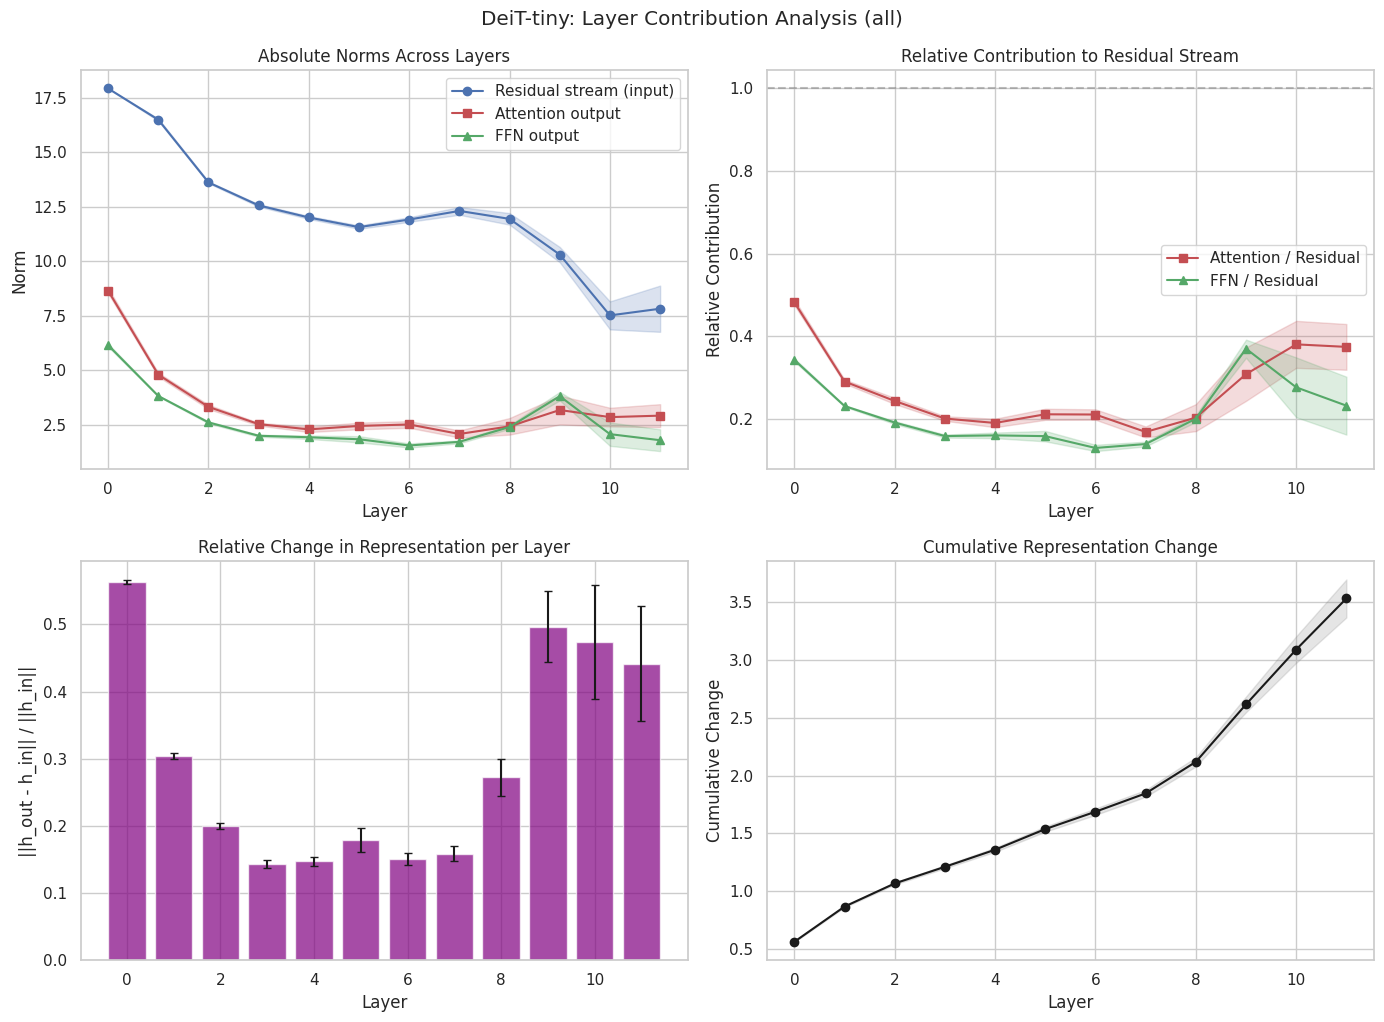

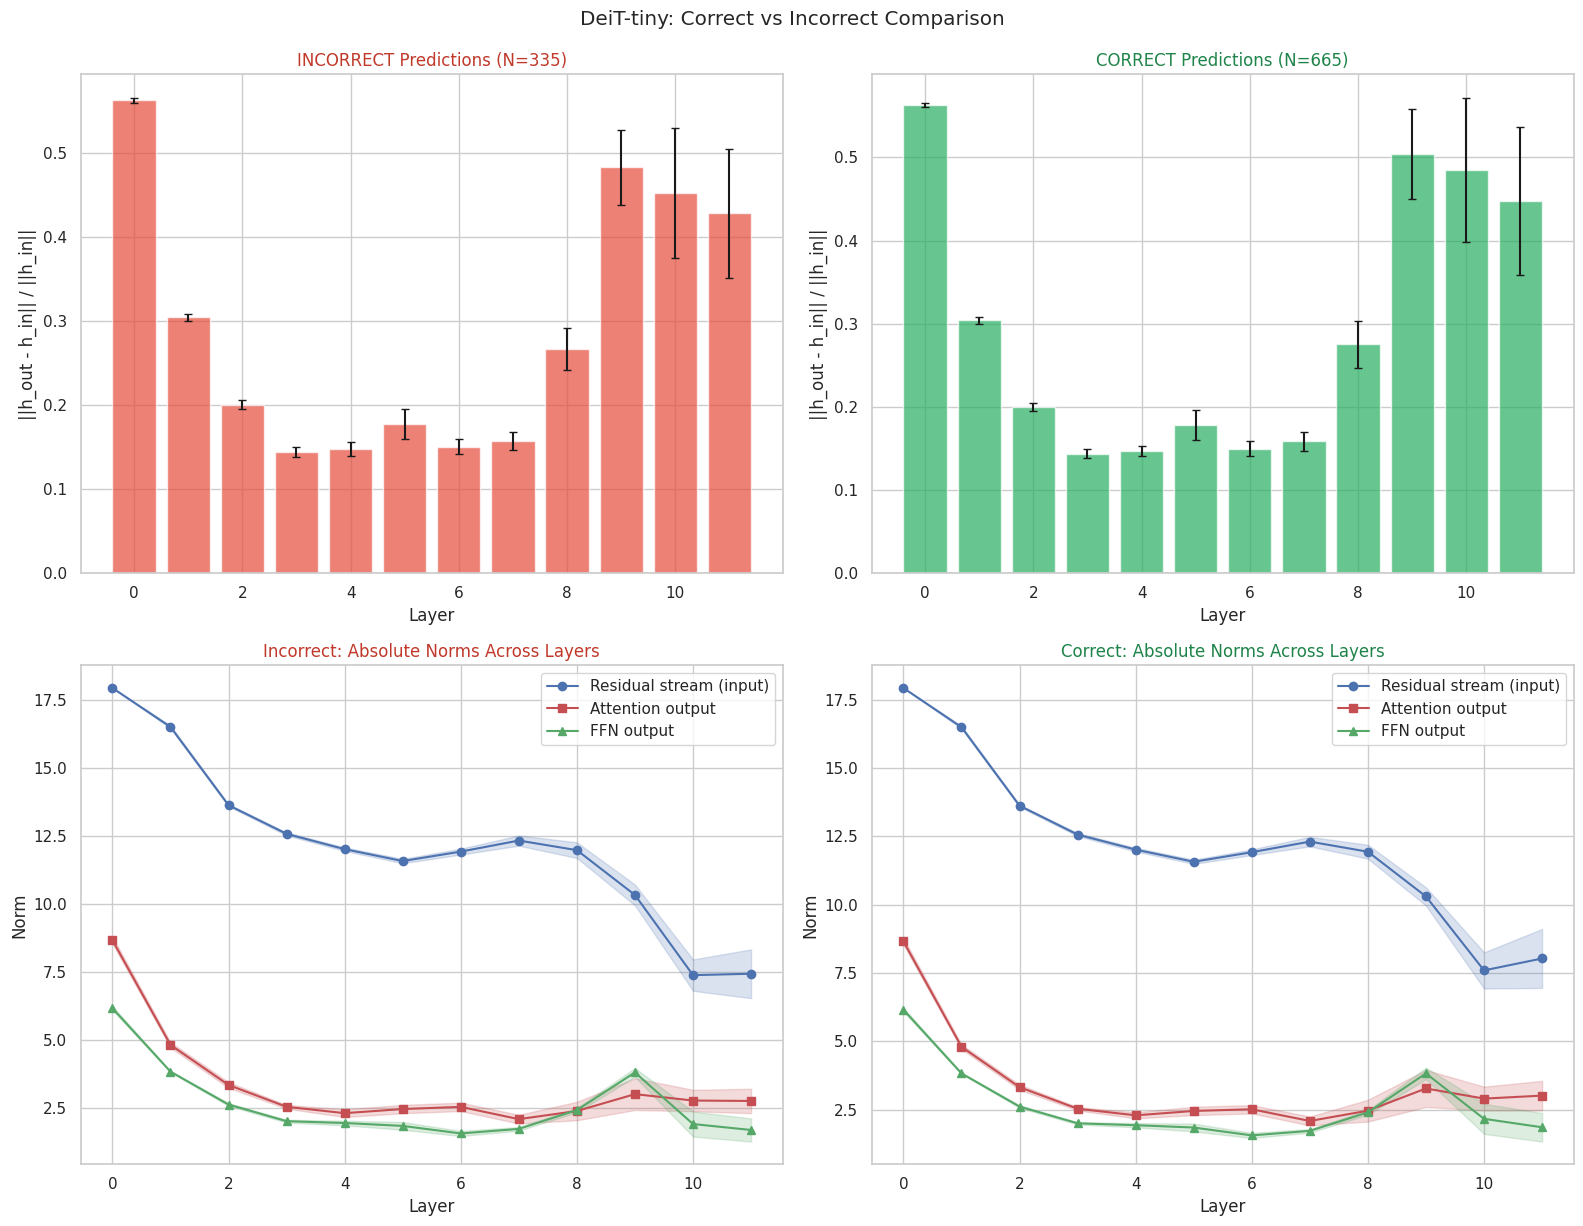

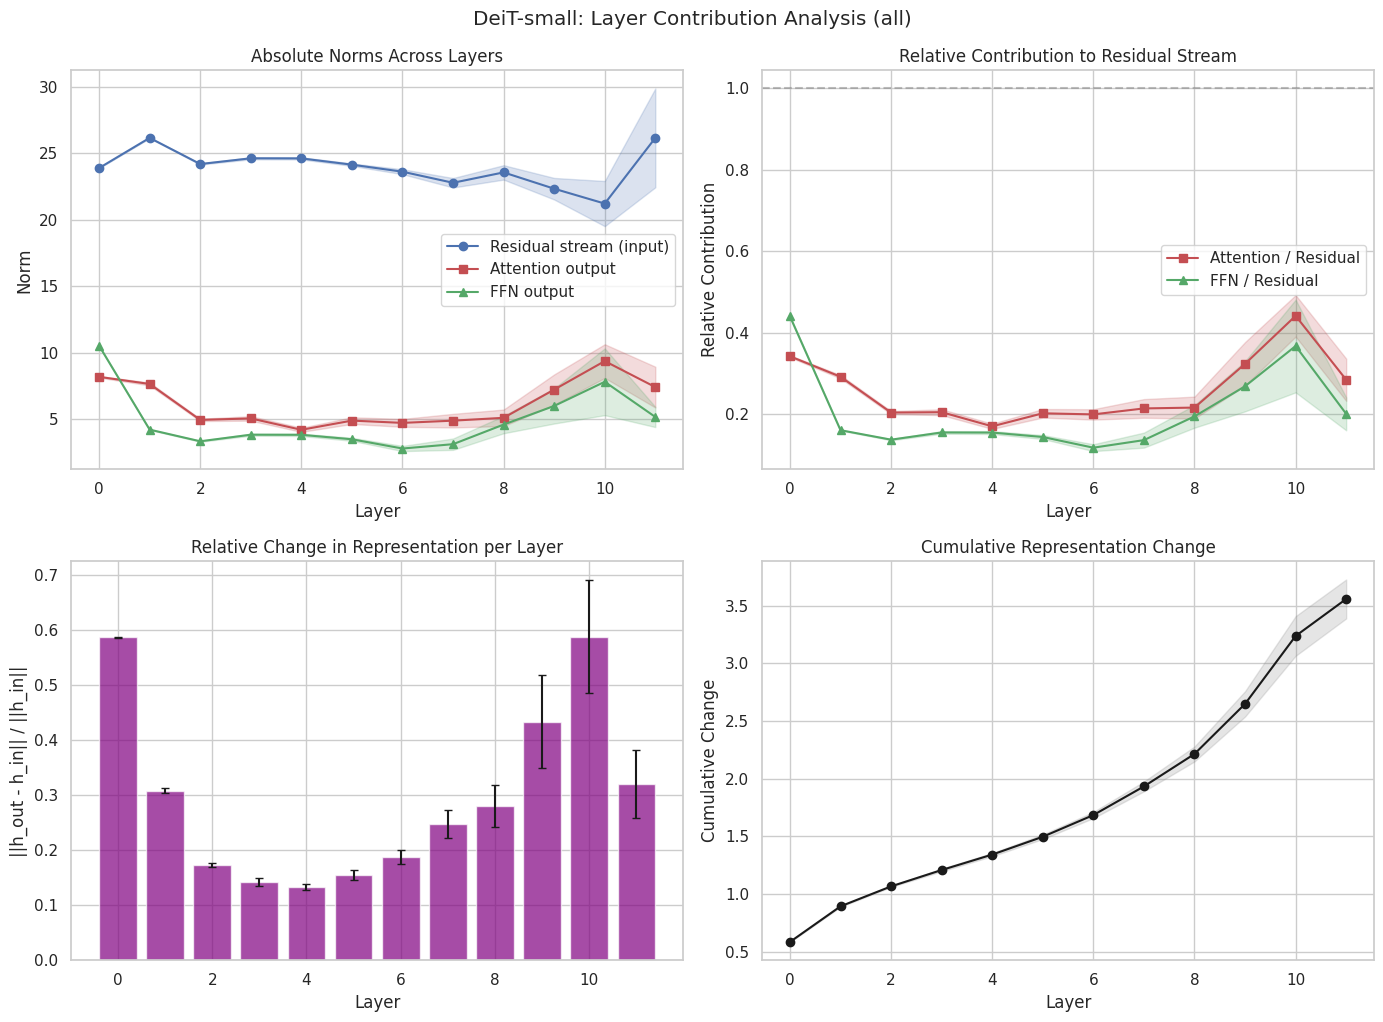

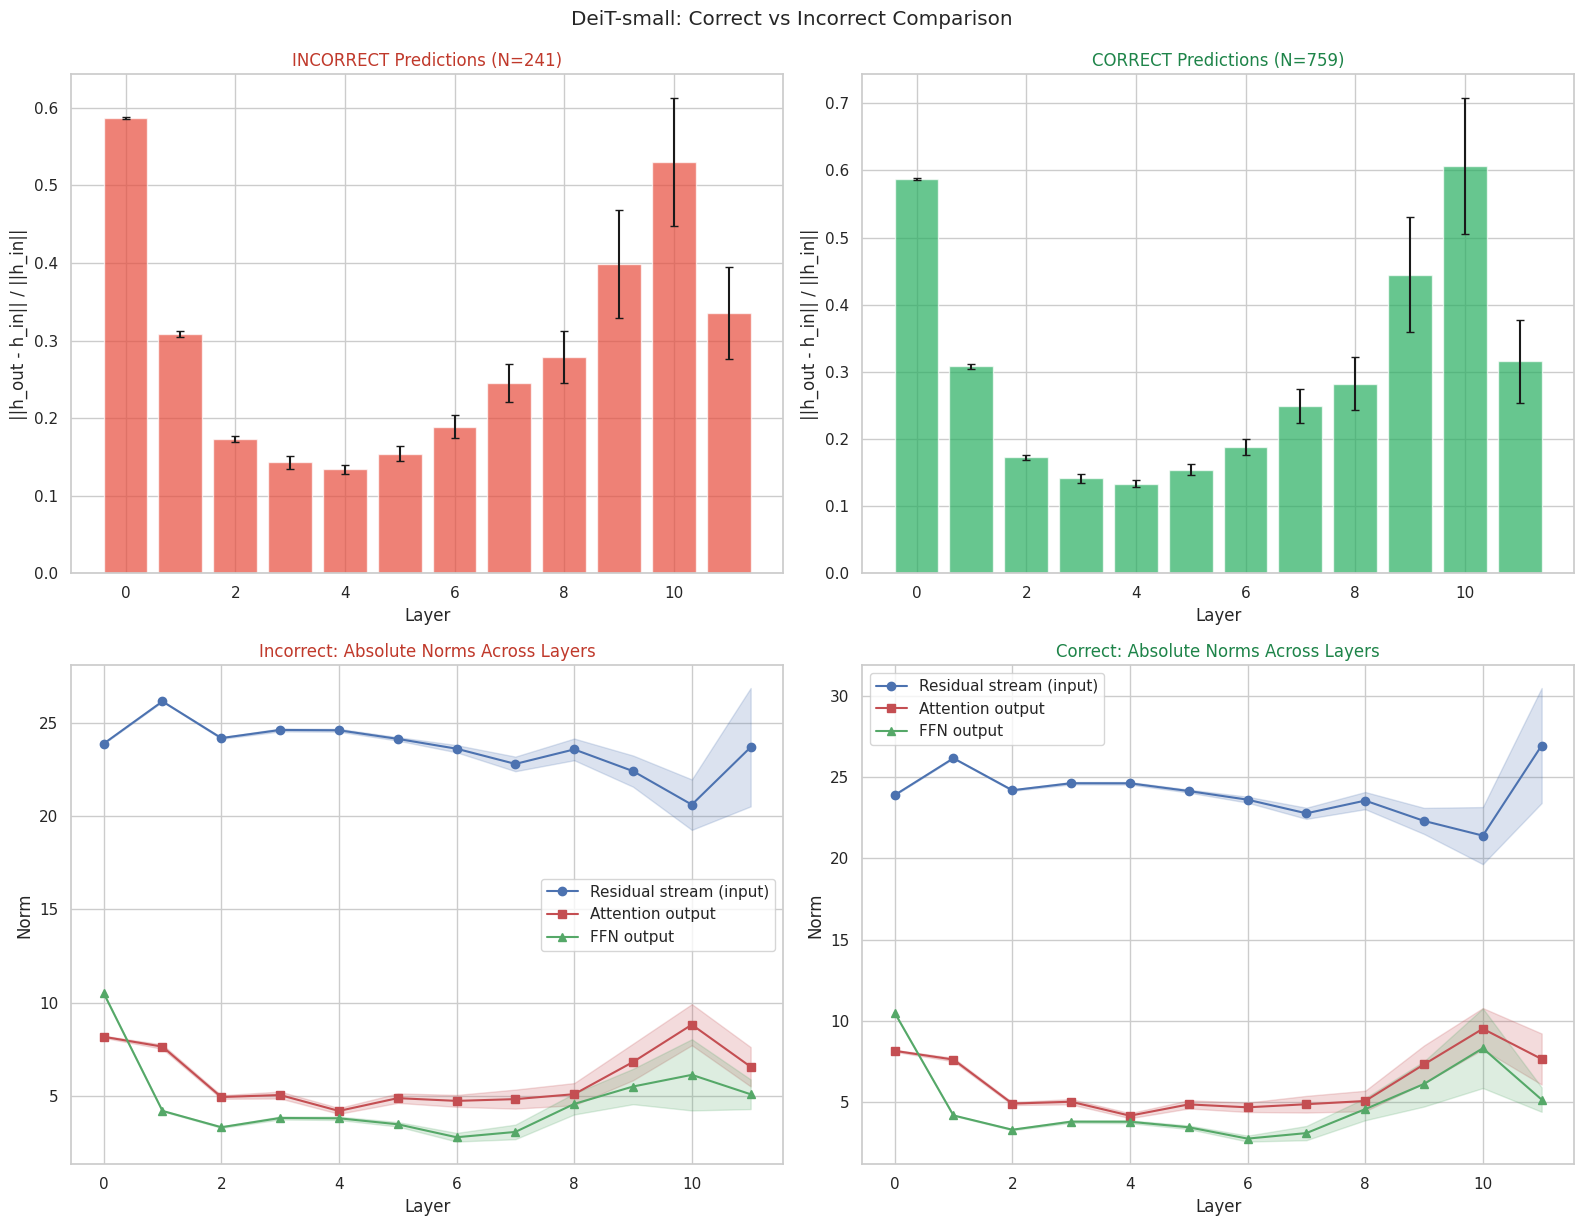

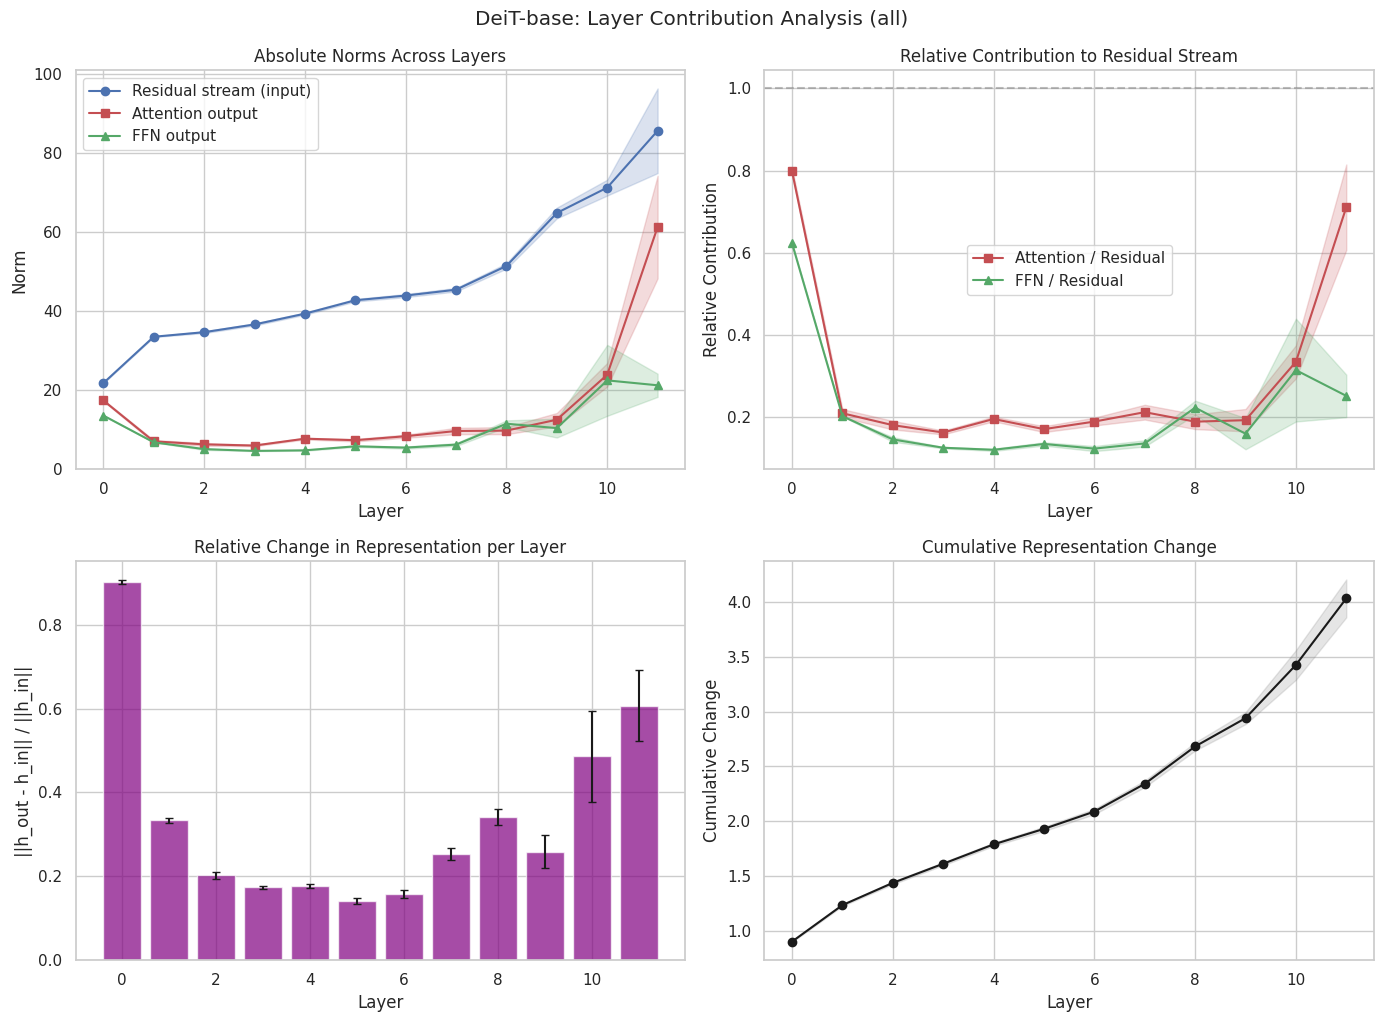

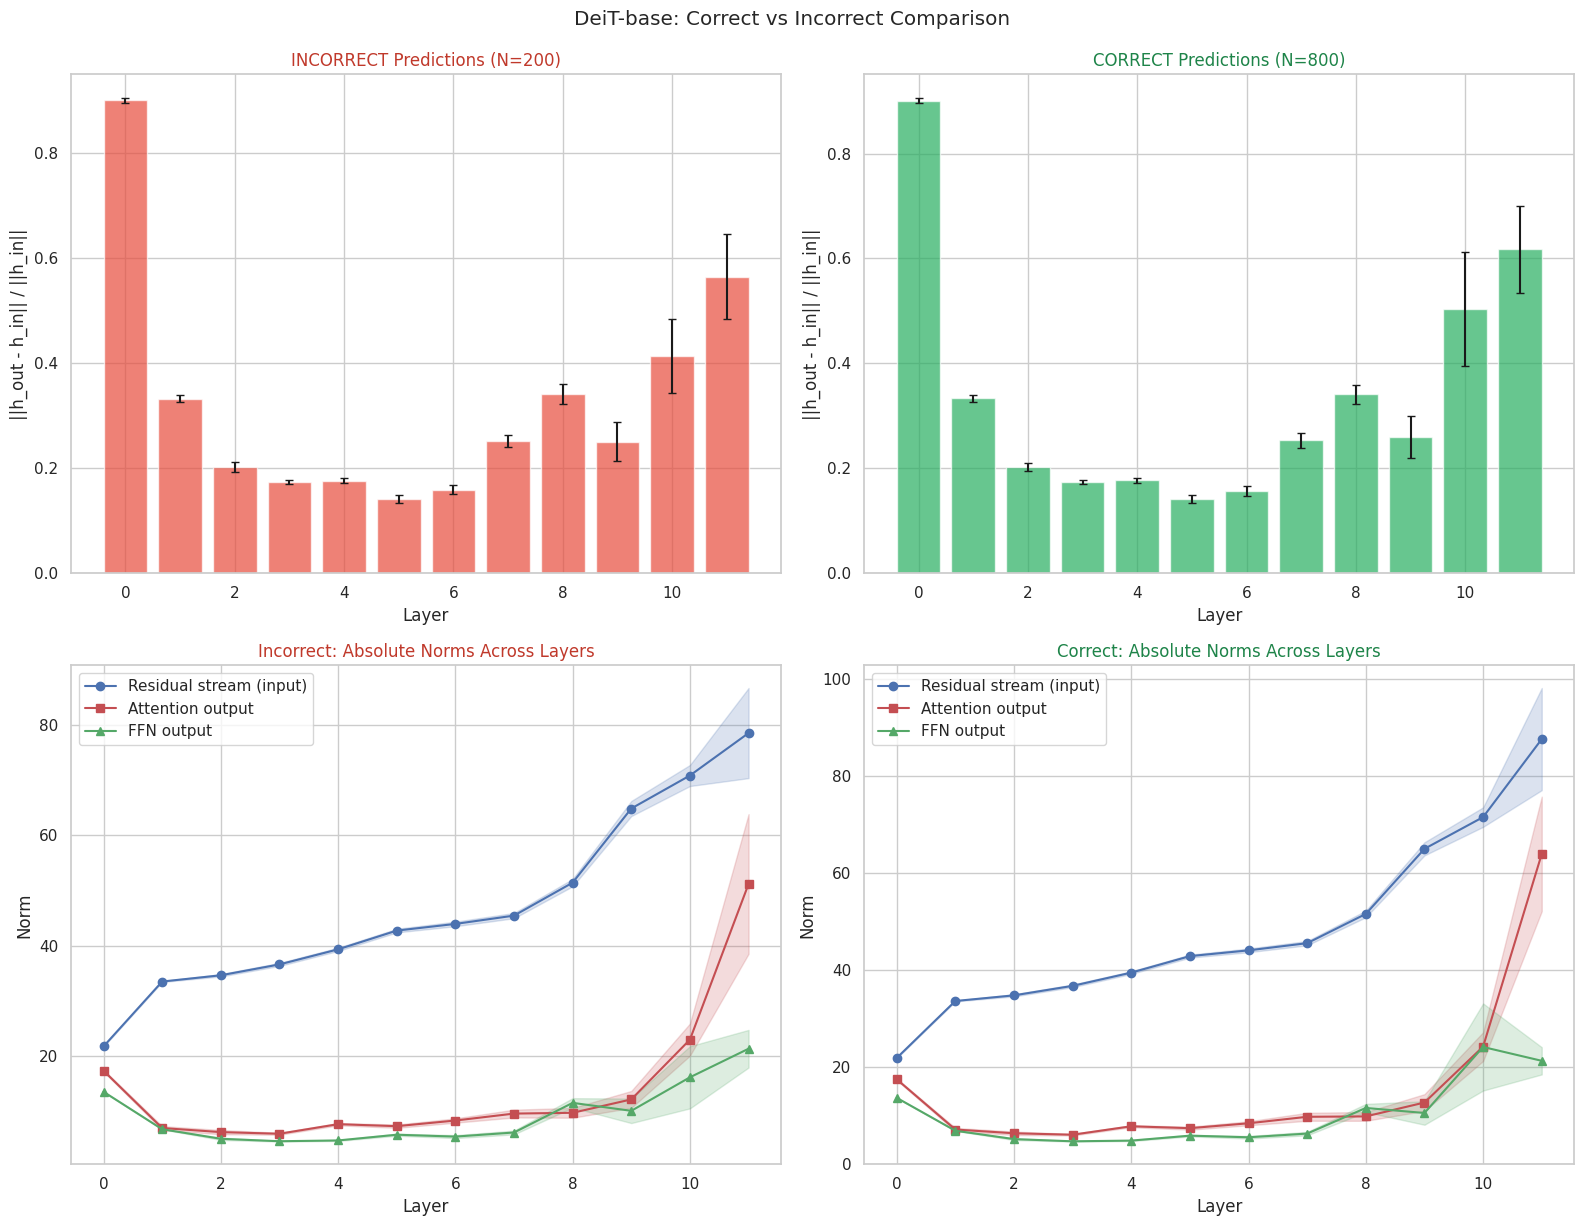

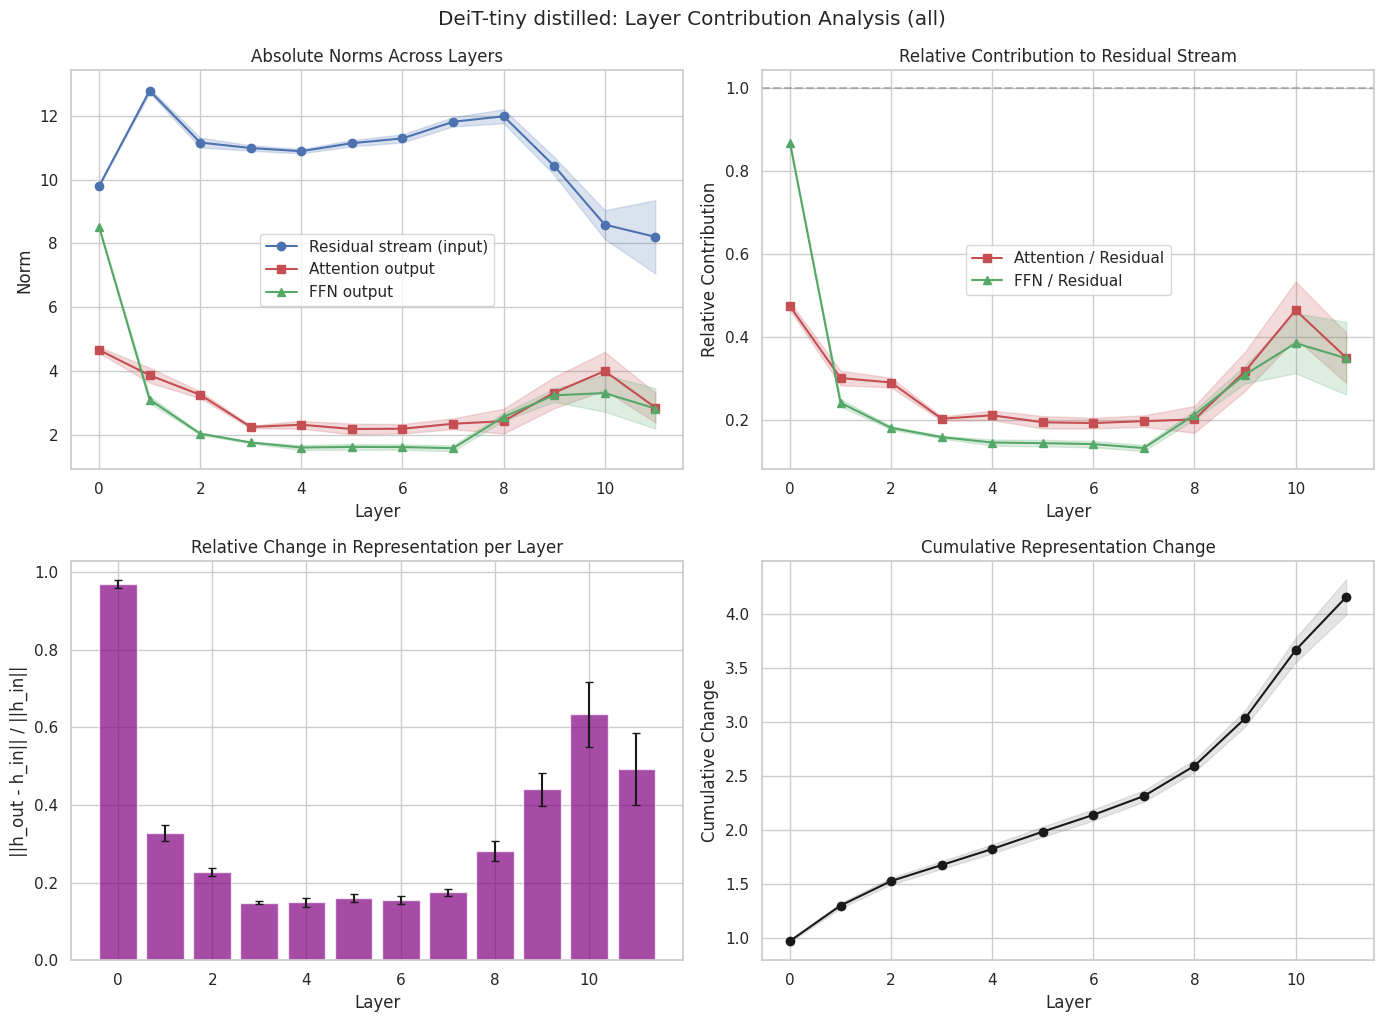

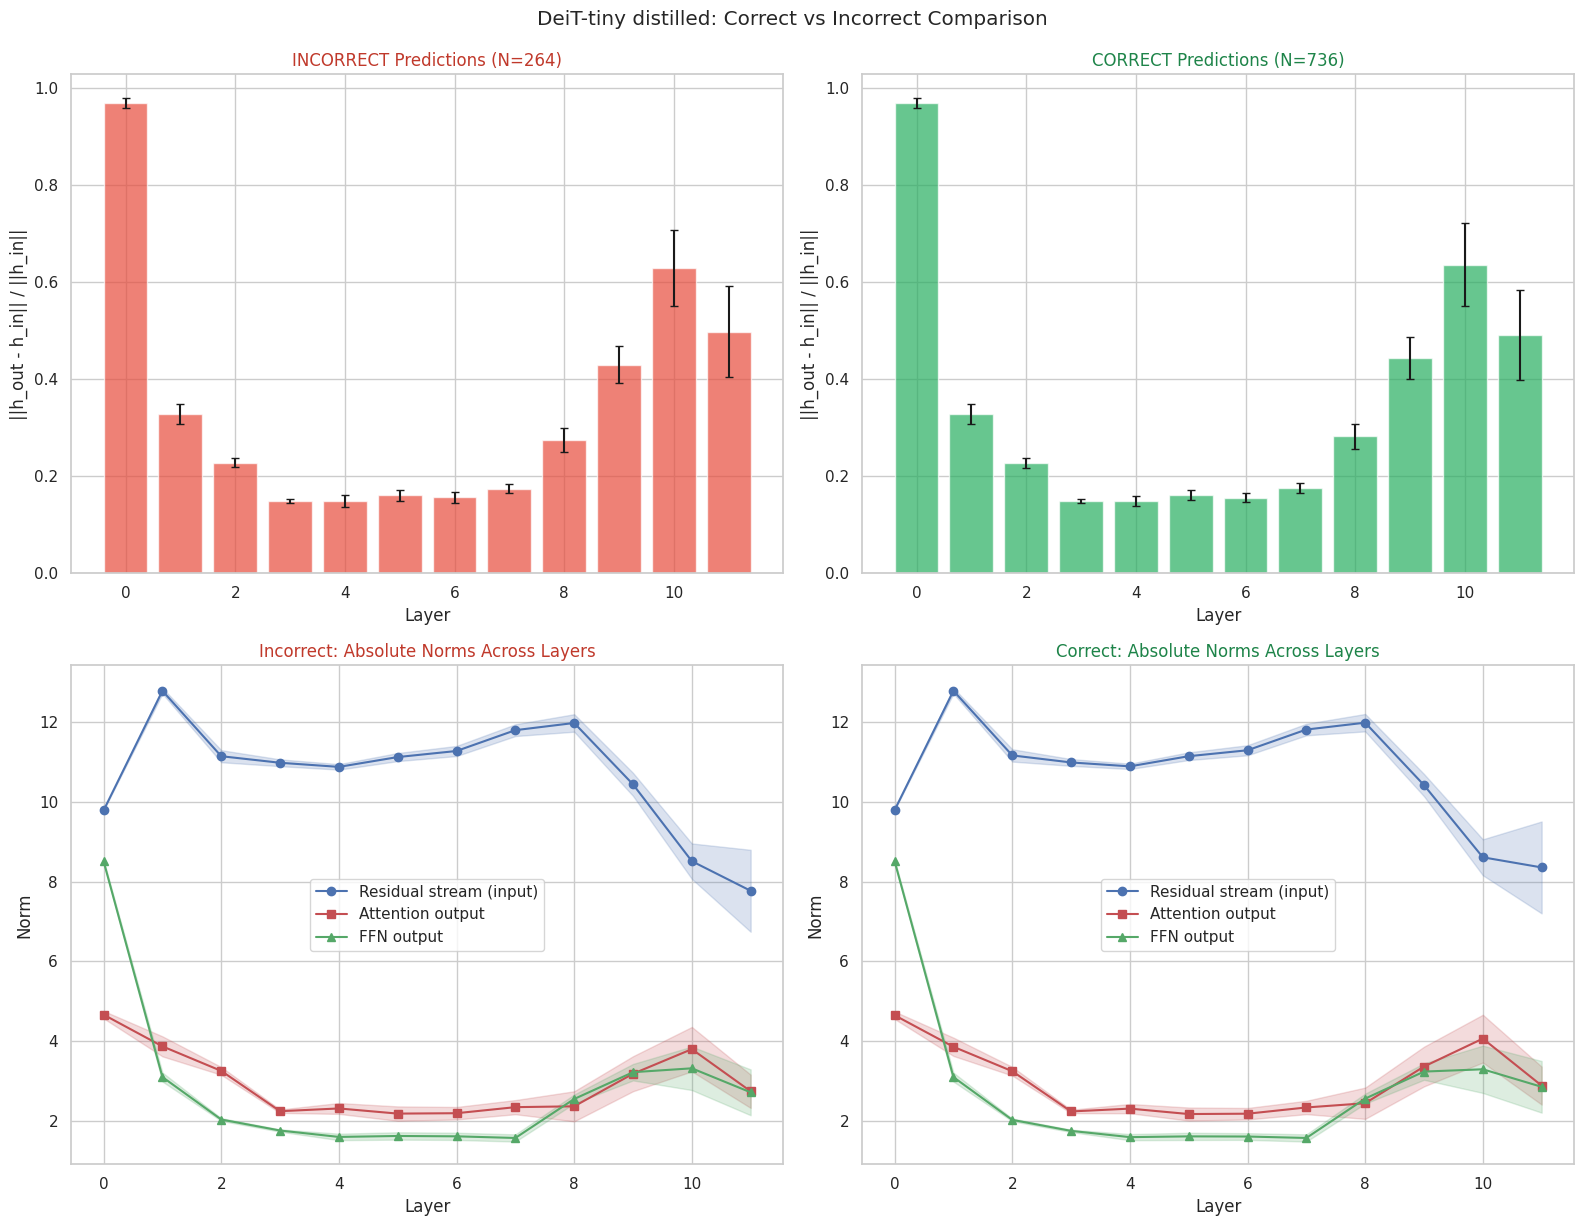

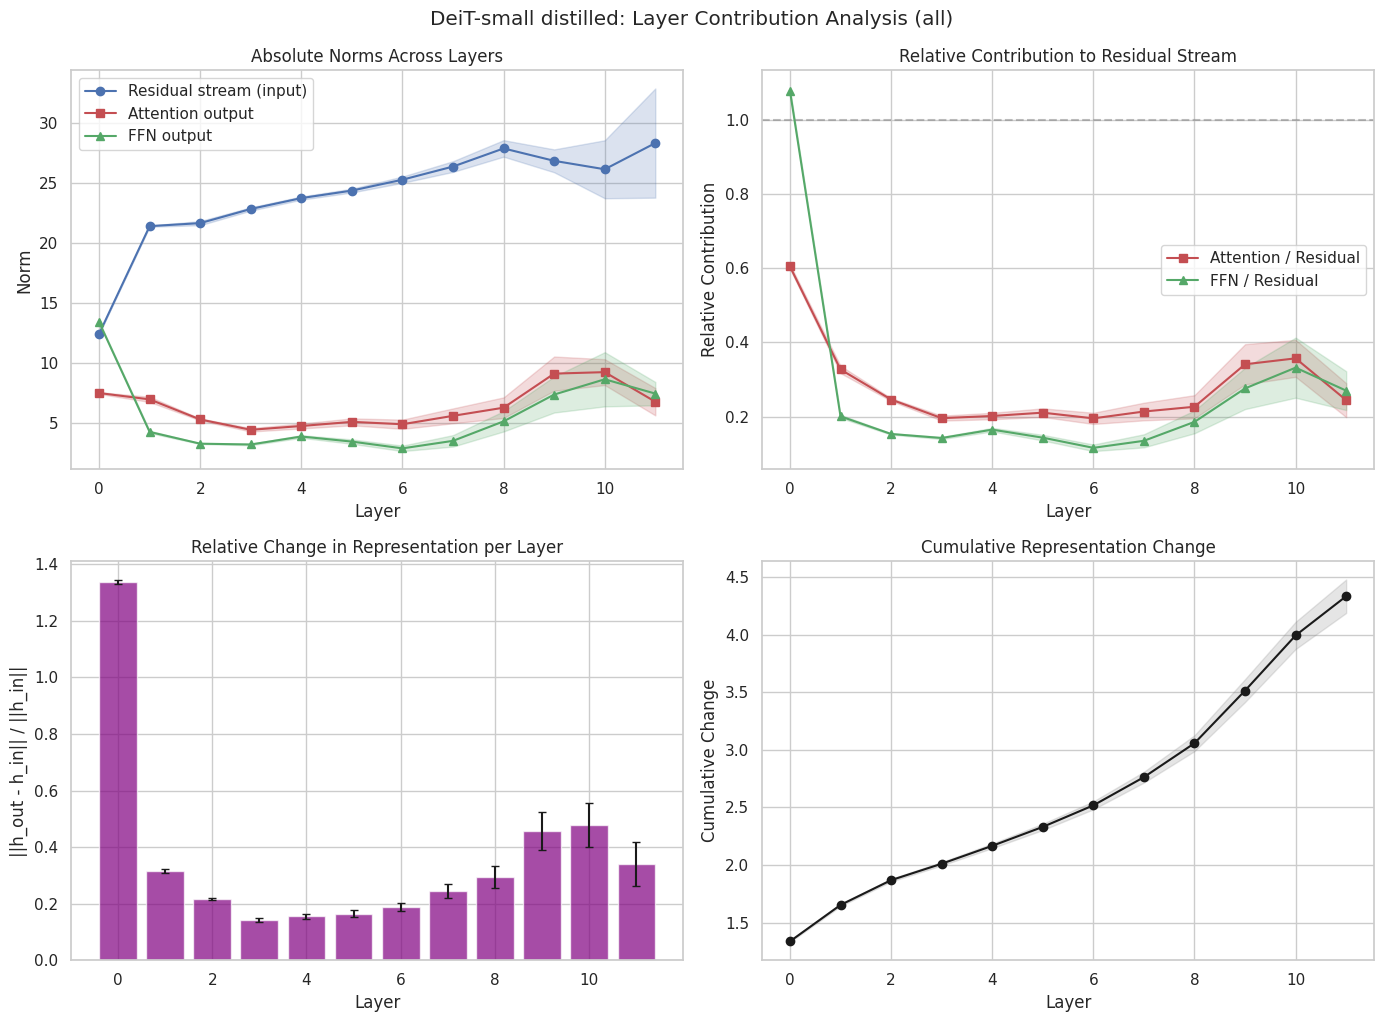

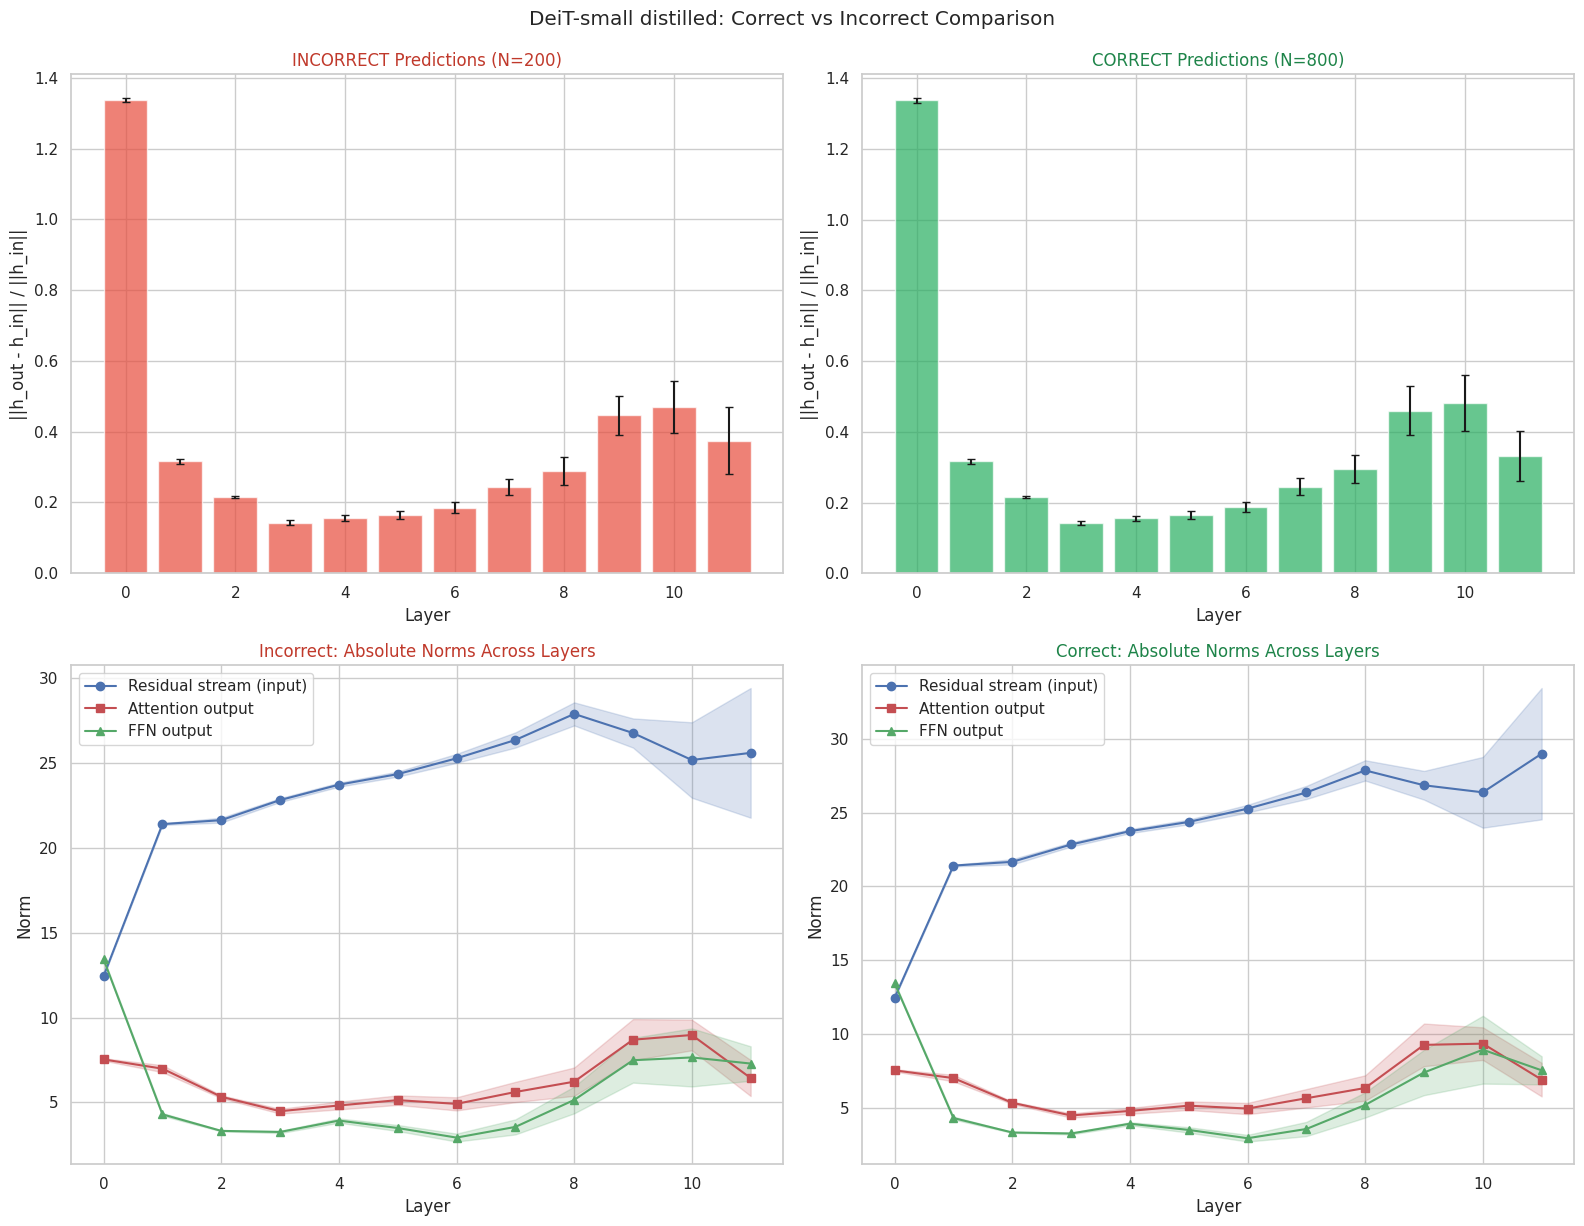

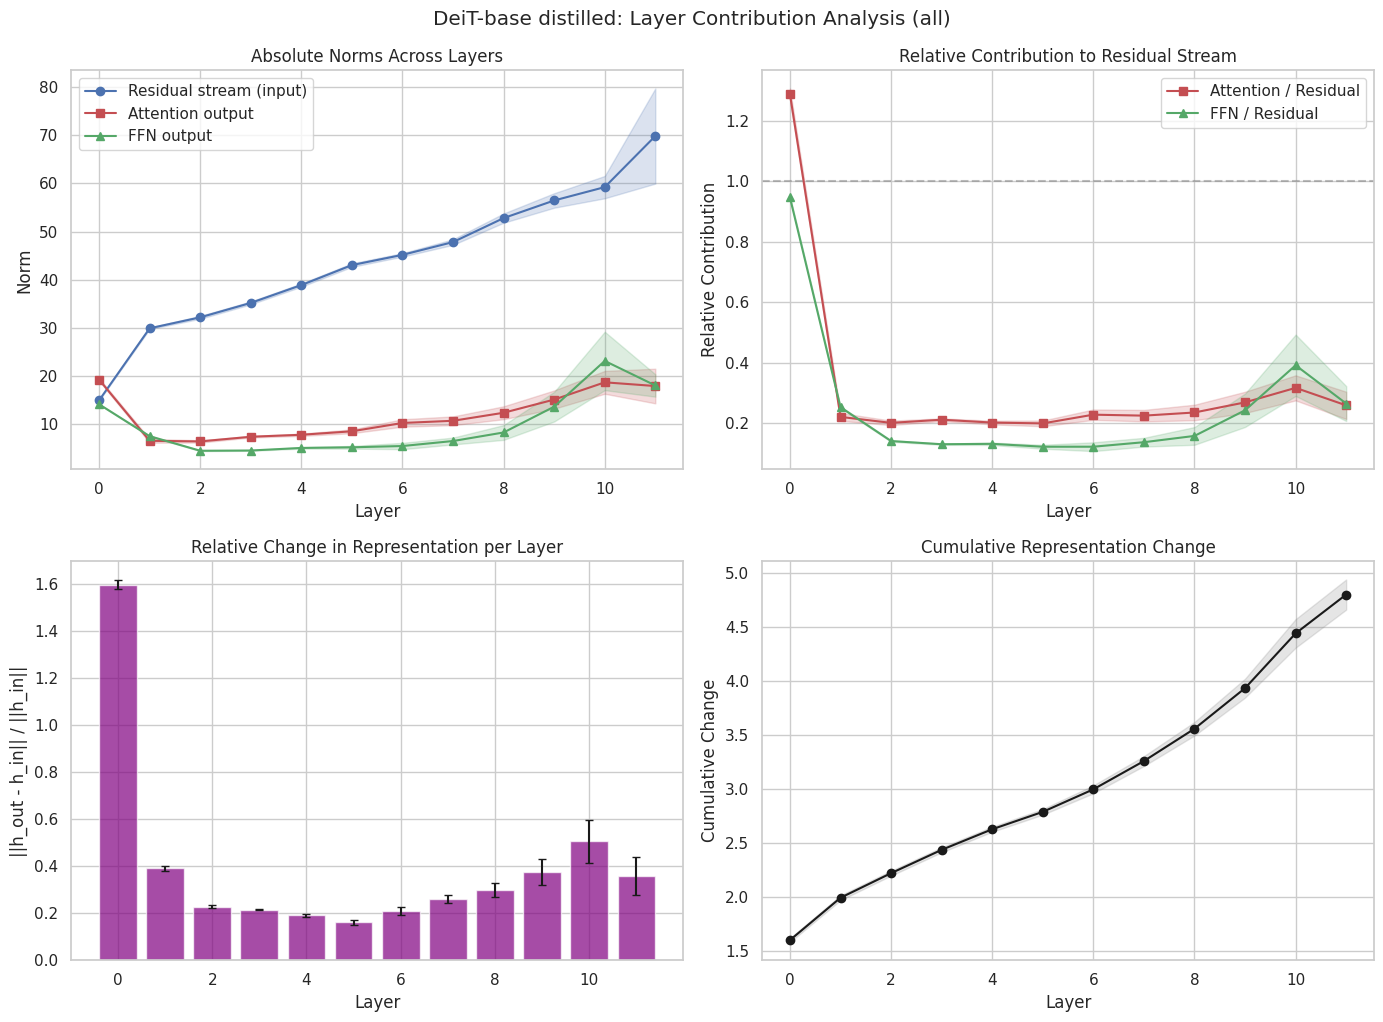

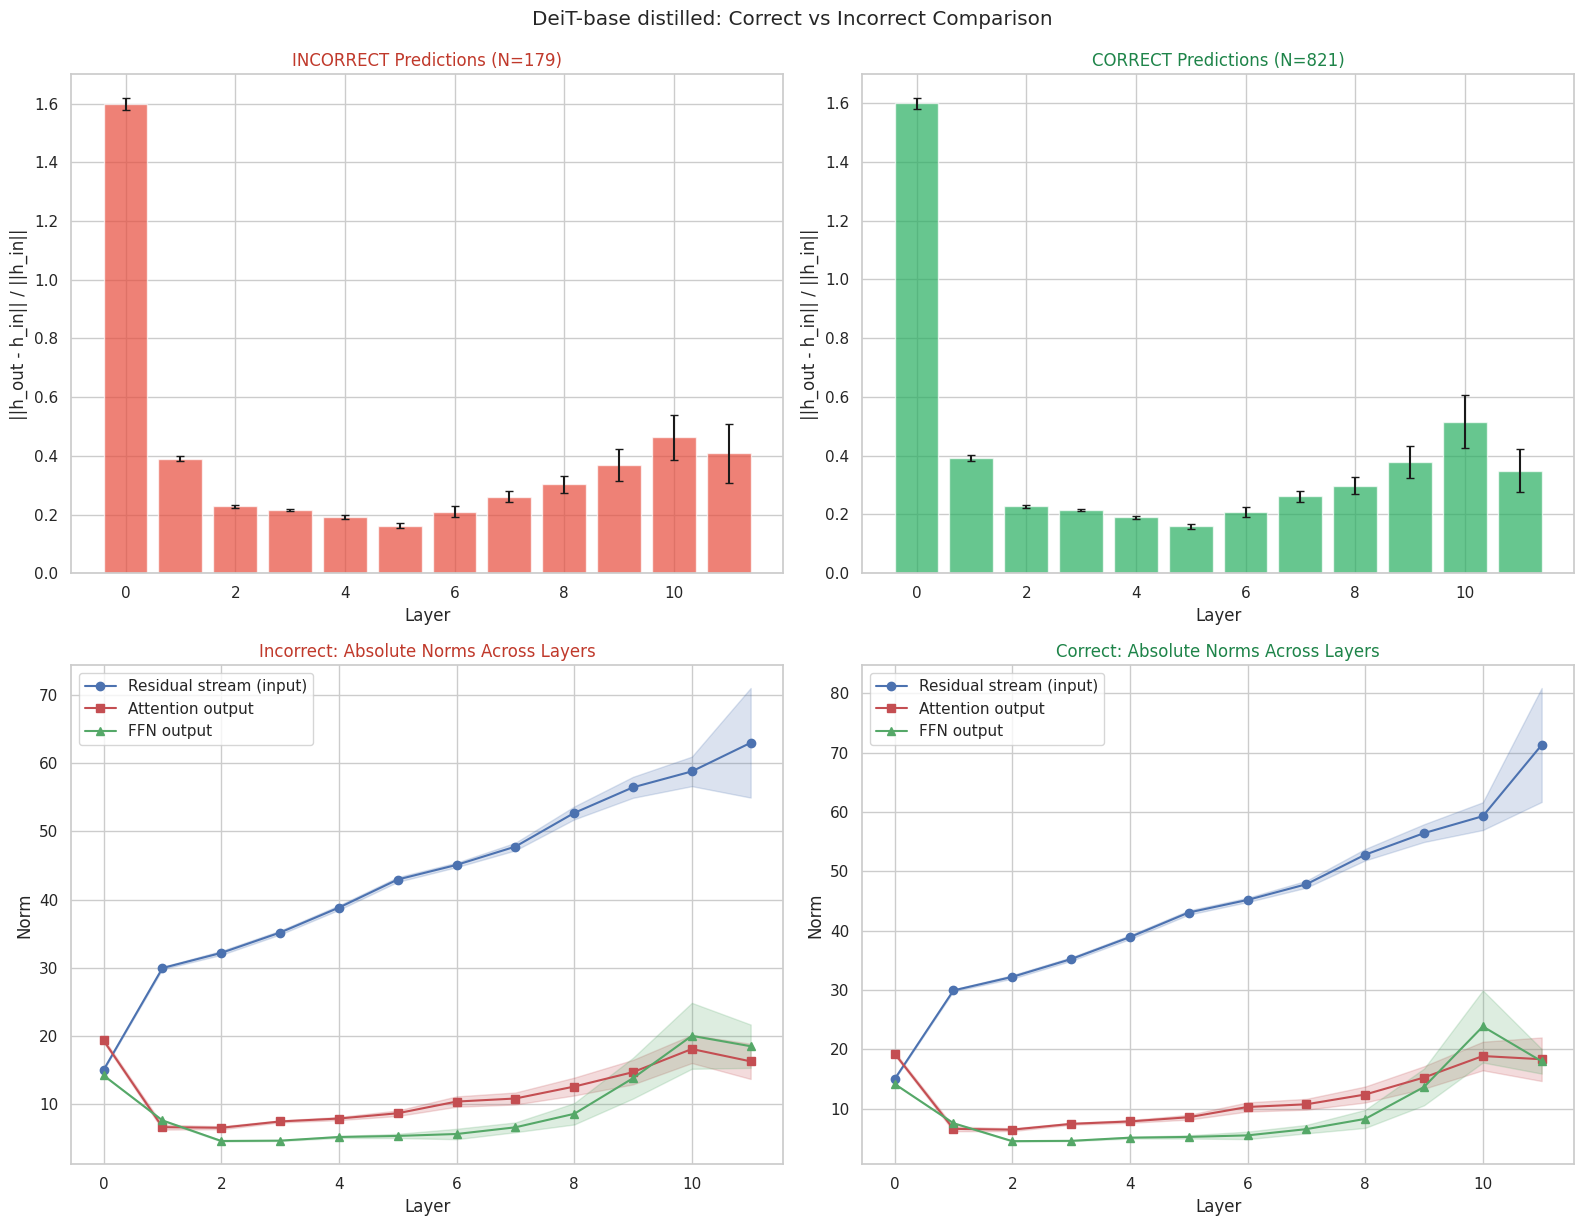

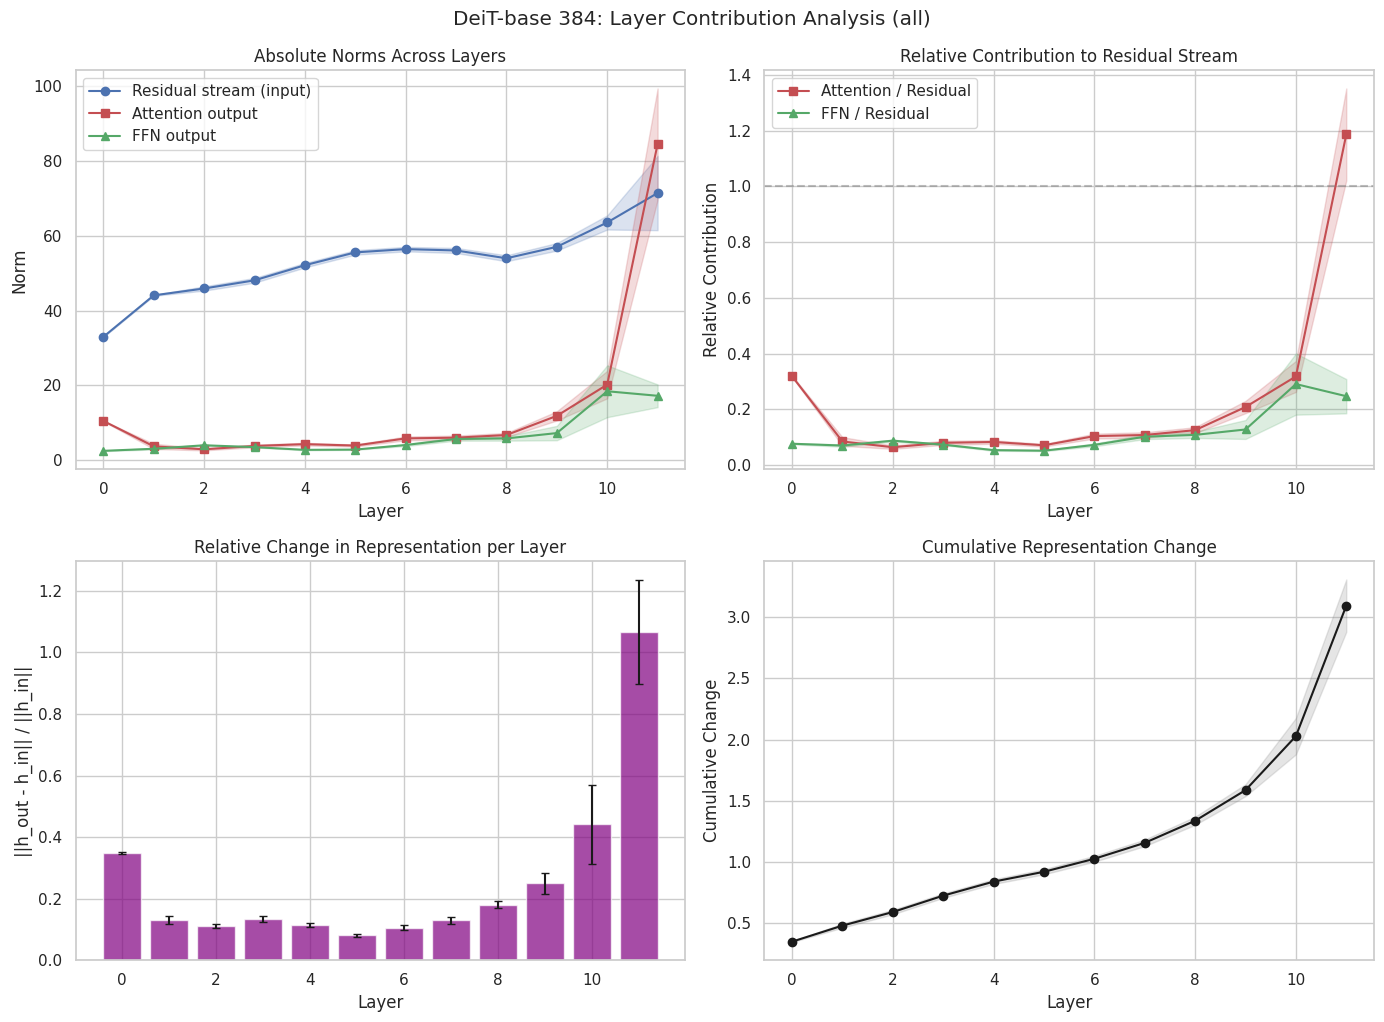

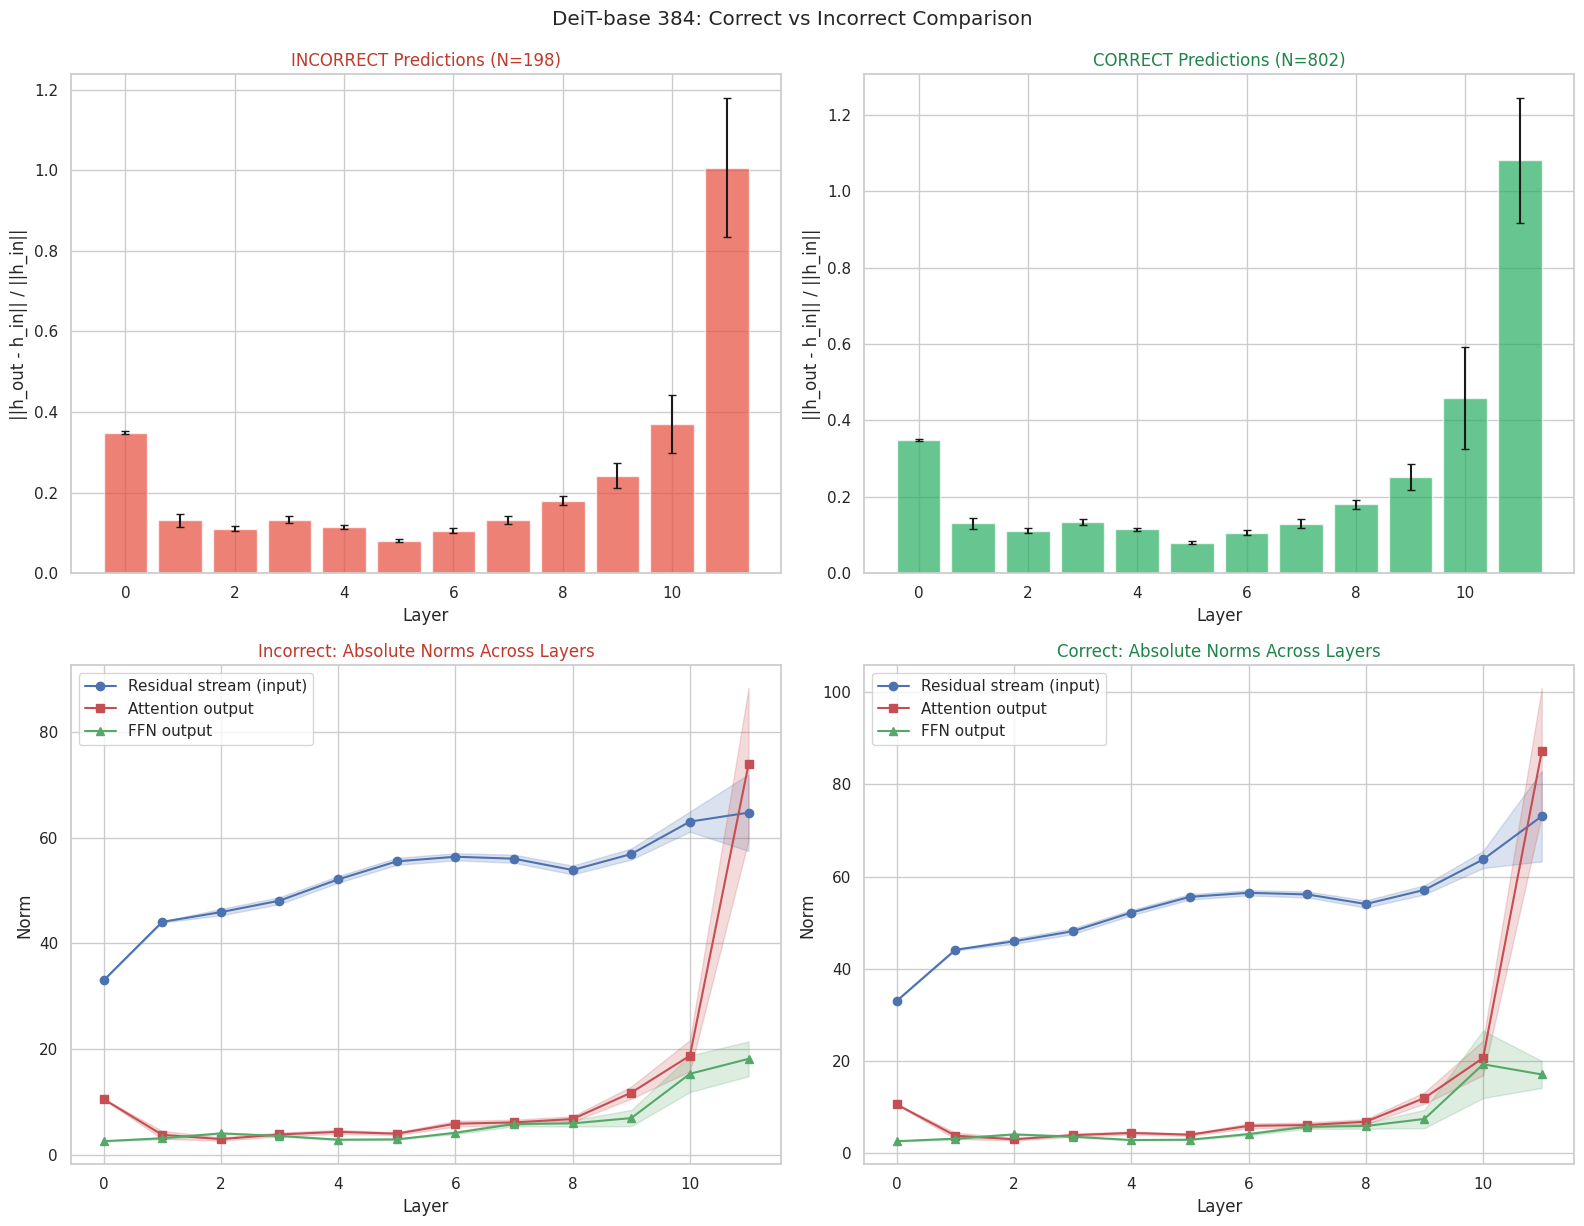

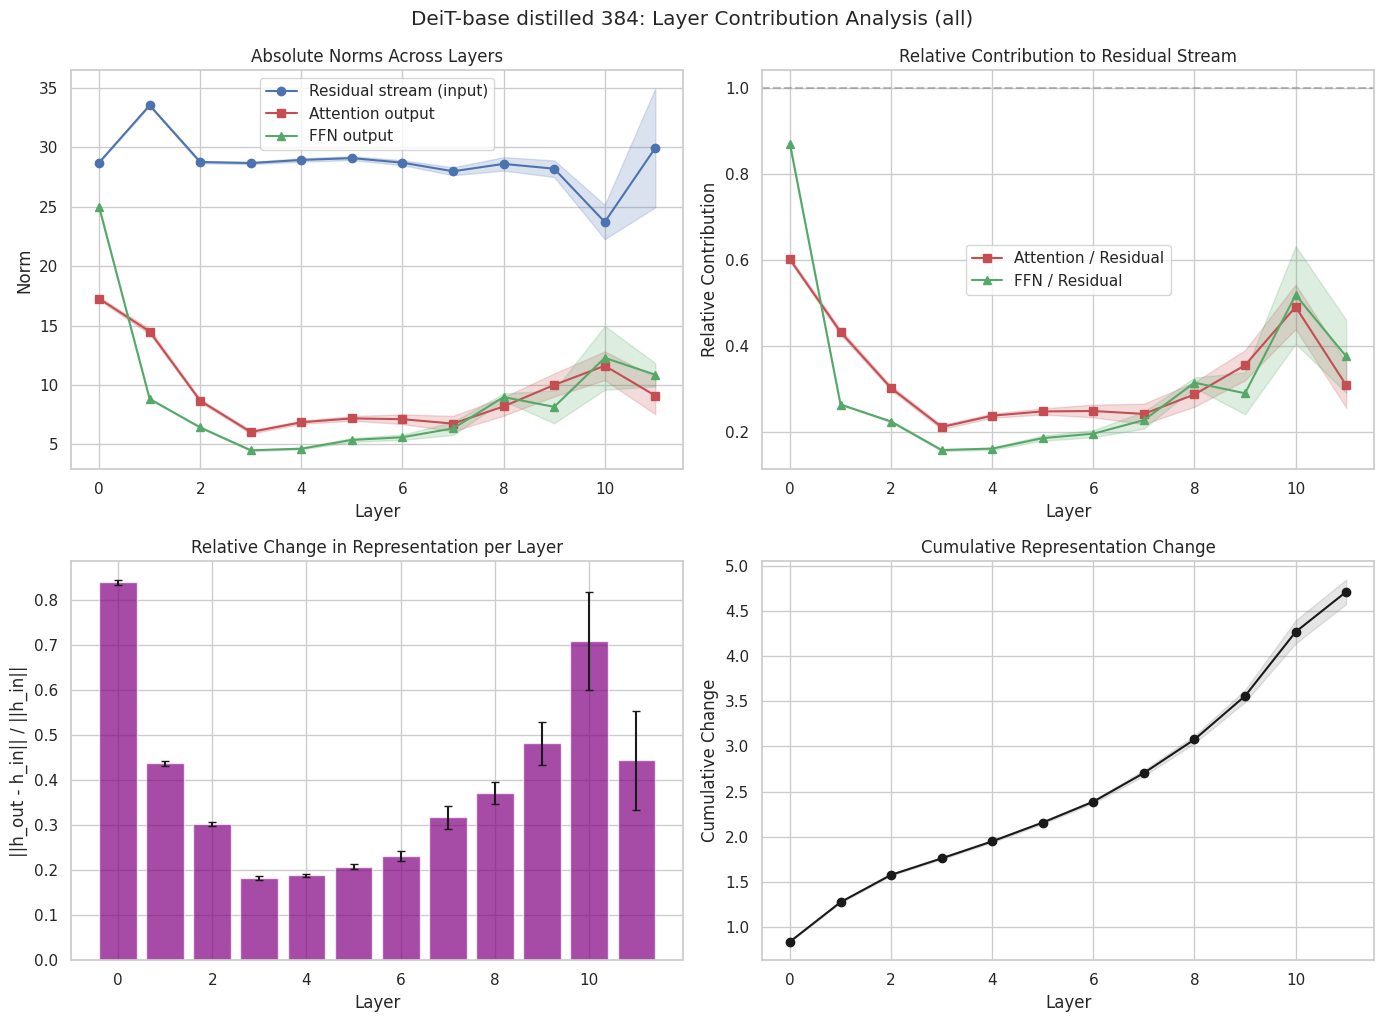

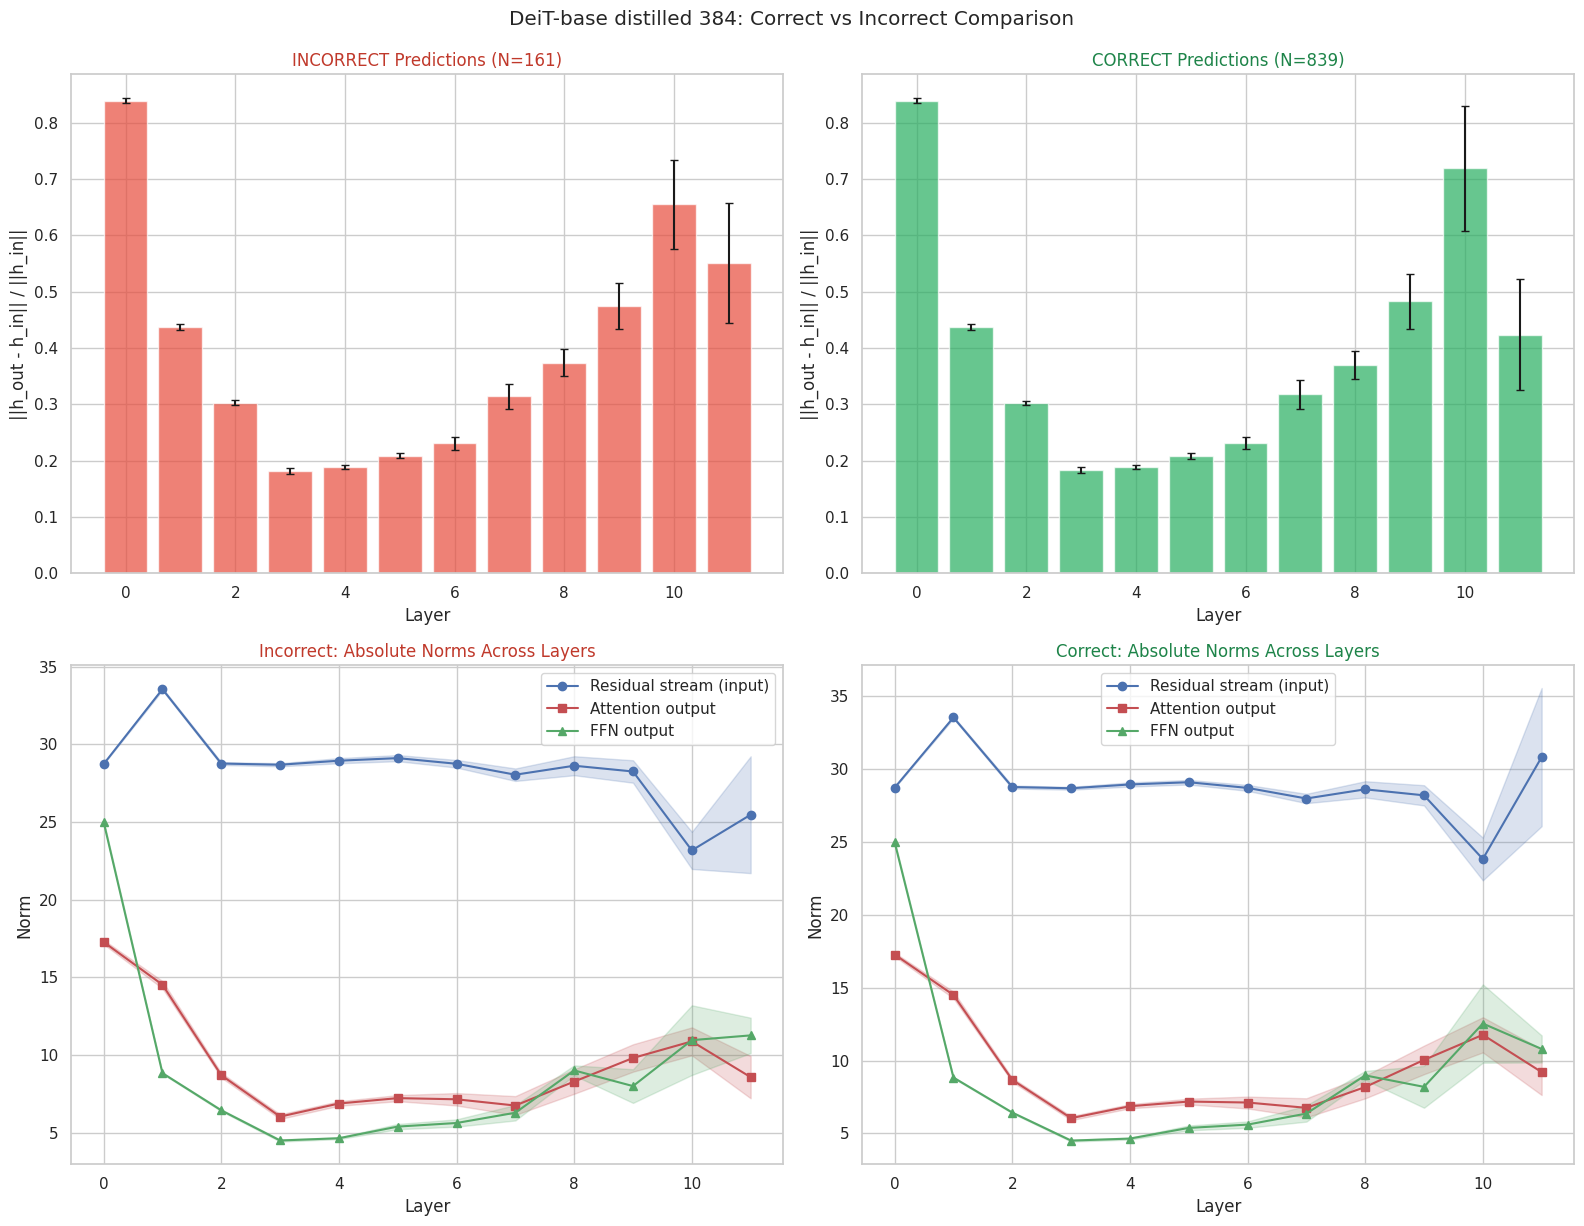

In [18]:
for spec in selected_specs:
    plot_layer_contribution_dashboard(contribution_raw_df, spec.name, split="all")
    plot_correct_vs_incorrect_dashboard(contribution_raw_df, spec.name)

In [19]:
noise_robustness_df = run_noise_robustness_suite(
    model_specs=selected_specs,
    dataset_split=dataset_split,
    config=EXPERIMENT_CONFIG,
)

fragility_df = run_fragility_suite(
    model_specs=selected_specs,
    dataset_split=dataset_split,
    config=EXPERIMENT_CONFIG,
)

noise_robustness_df.head(), fragility_df.head()


Running noise robustness for DeiT-tiny...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Encoding accuracy batches:   0%|          | 0/32 [00:00<?, ?it/s]

Running noise robustness for DeiT-small...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Encoding accuracy batches:   0%|          | 0/32 [00:00<?, ?it/s]

Running layer fragility analysis for DeiT-base distilled 384...


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Encoding accuracy batches:   0%|          | 0/32 [00:00<?, ?it/s]

(  model_name                         repo_id target_layers  alpha  accuracy  \
 0  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   0.00     68.36   
 1  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   0.25     58.98   
 2  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   0.50     36.91   
 3  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   0.75      4.10   
 4  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   1.00      0.39   
 
    baseline_accuracy  accuracy_drop  samples_evaluated  
 0              68.36           0.00                500  
 1              68.36           9.38                500  
 2              68.36          31.45                500  
 3              68.36          64.26                500  
 4              68.36          67.97                500  ,
   model_name                         repo_id  layer  alpha  accuracy  \
 0  DeiT-tiny  facebook/deit-tiny-patch16-224      7   0.00     68.36   
 1  DeiT-tiny  facebook

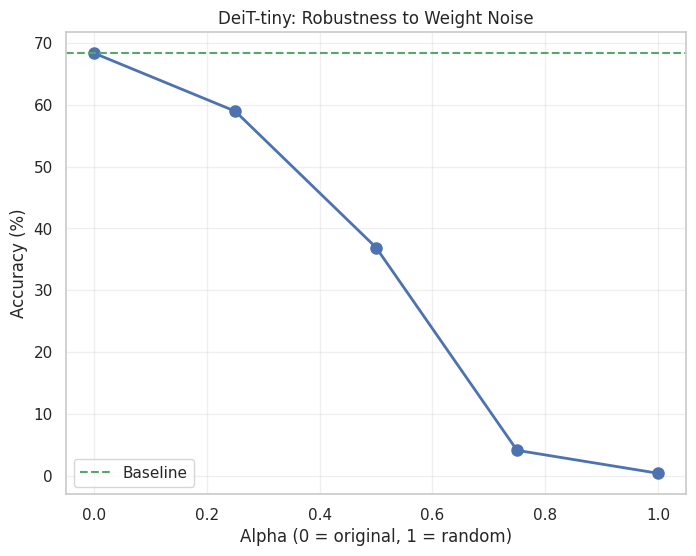

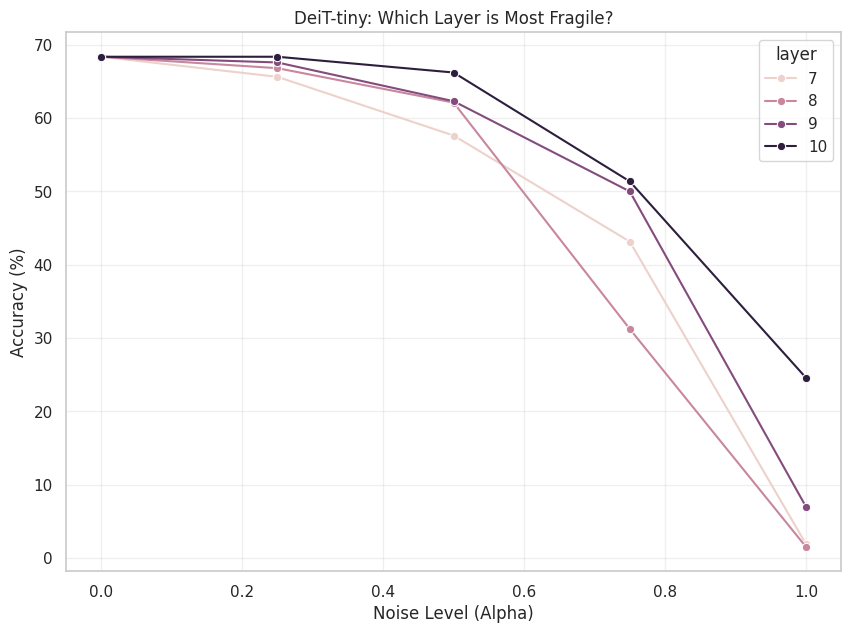

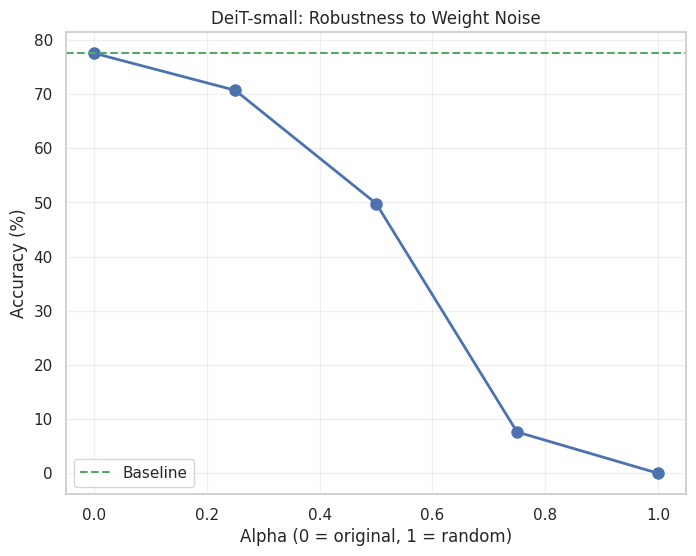

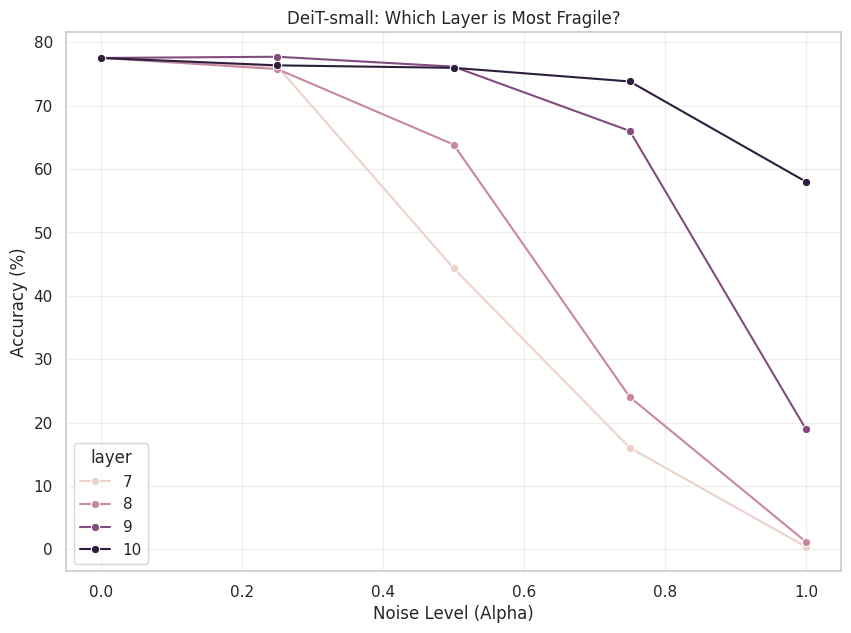

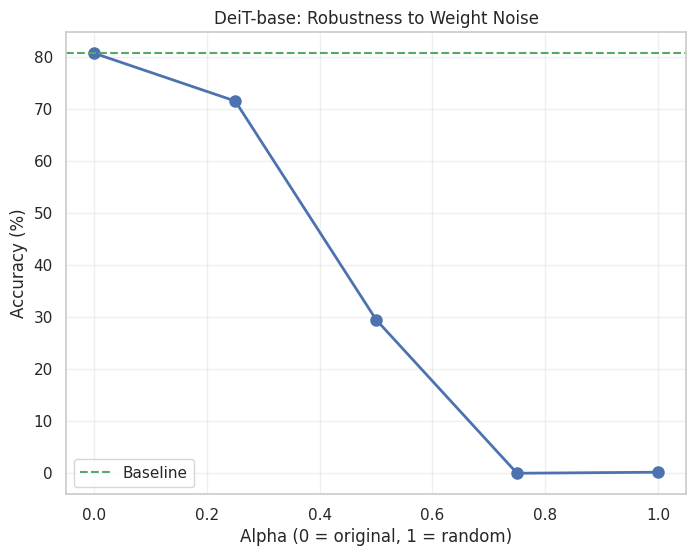

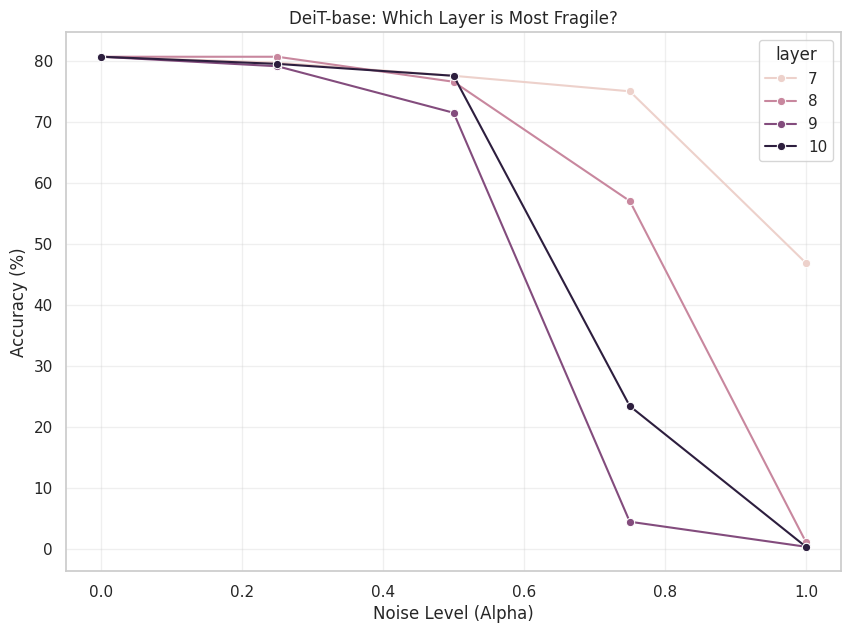

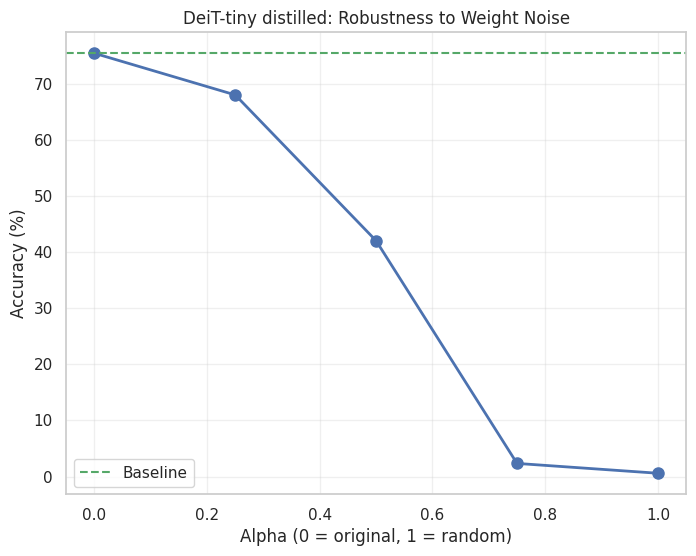

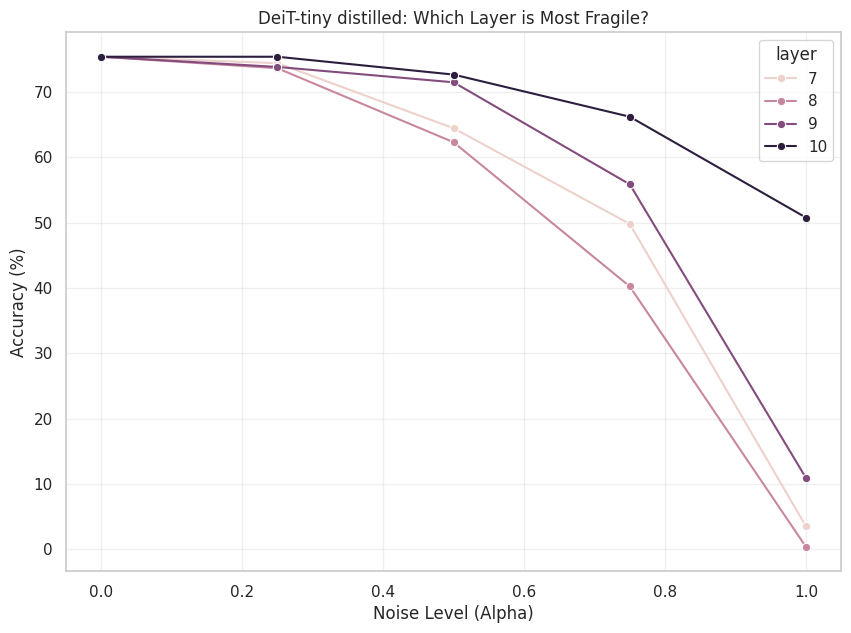

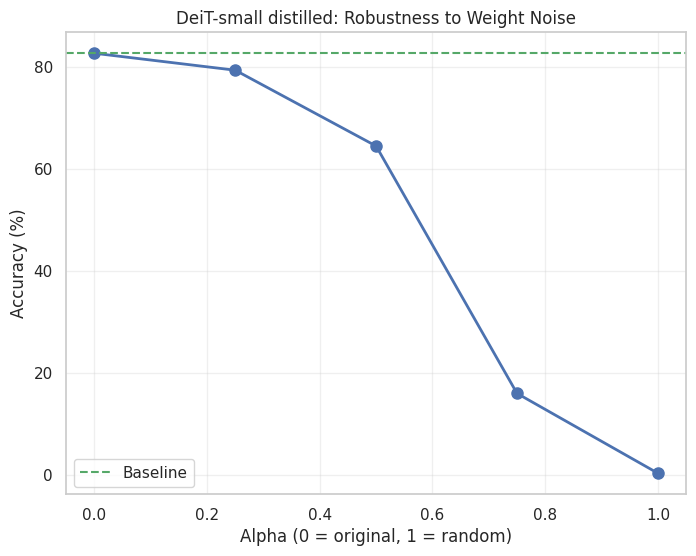

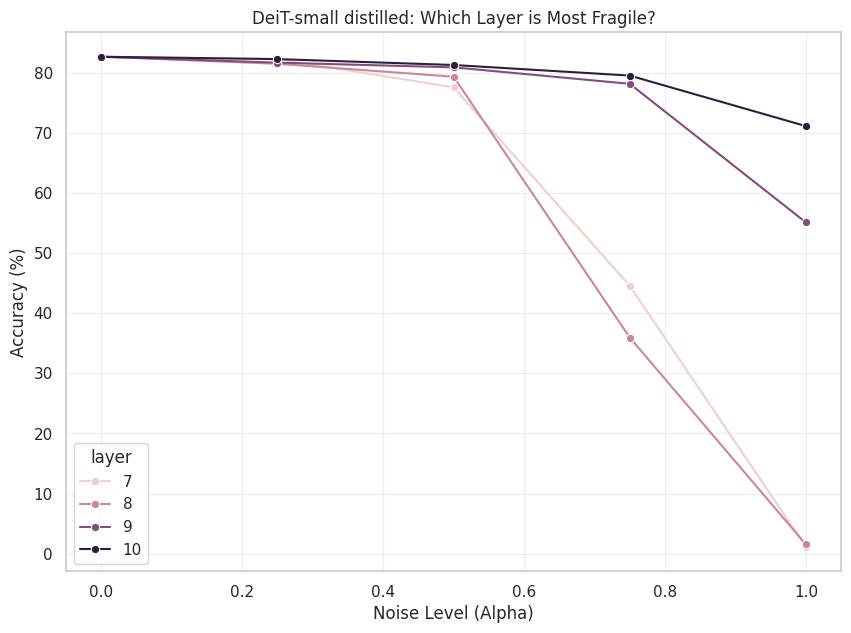

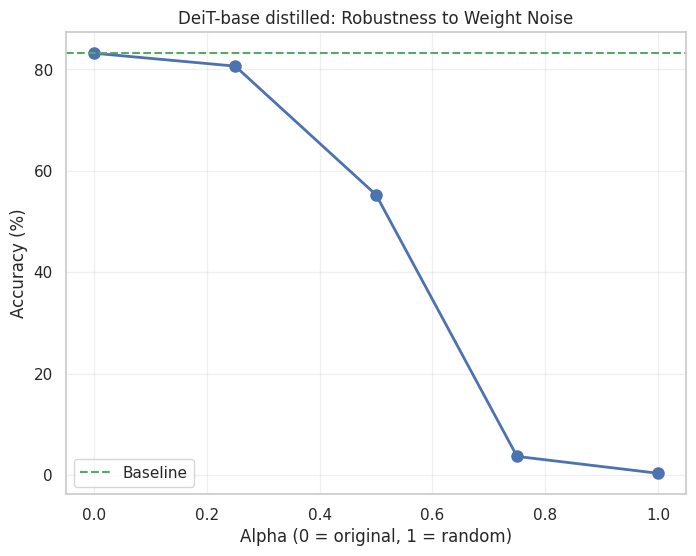

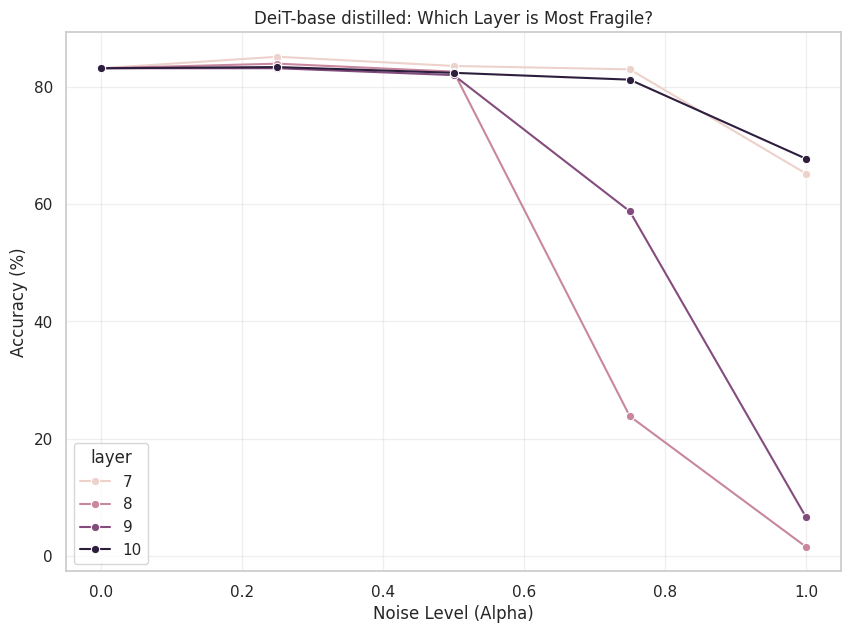

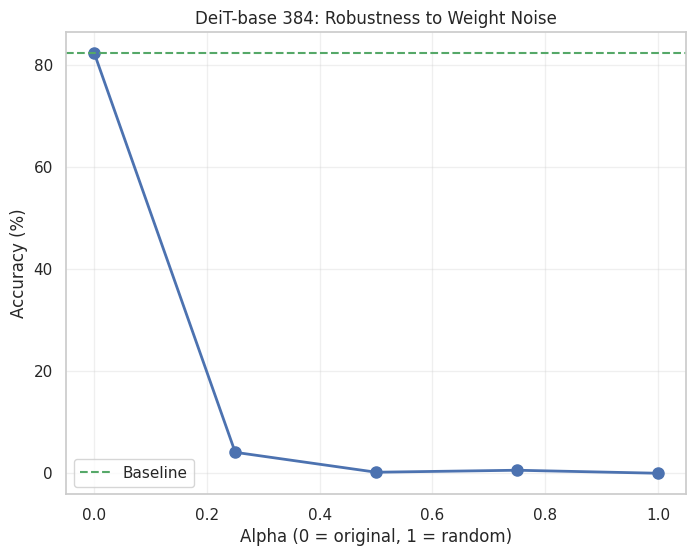

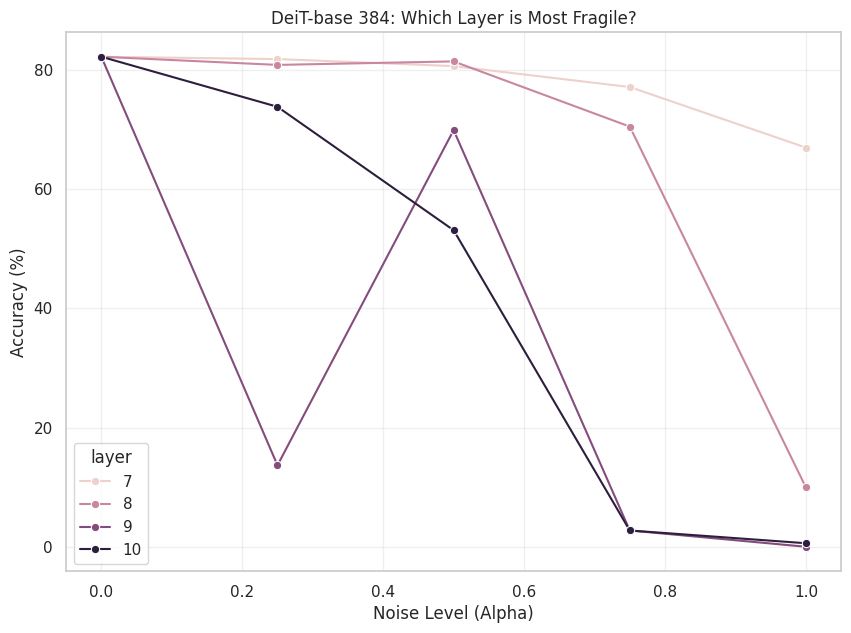

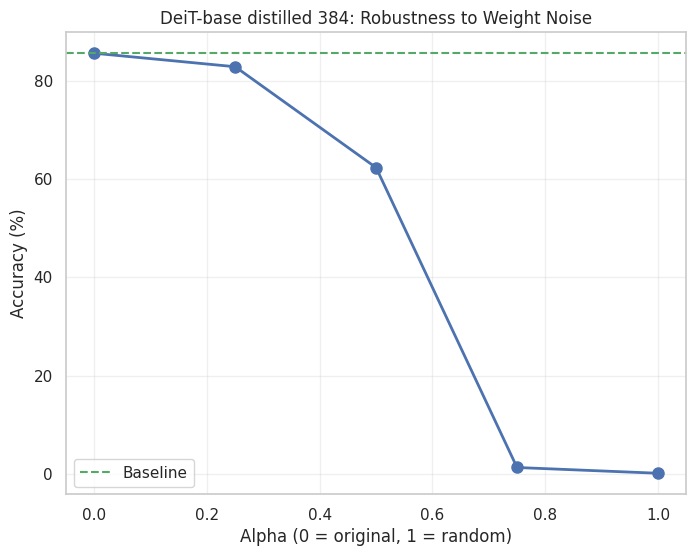

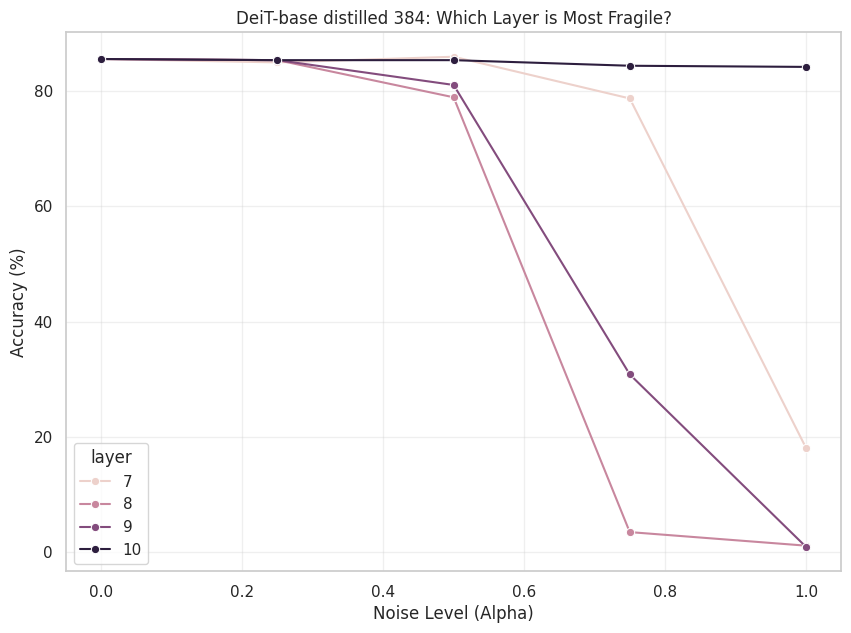

In [20]:
for spec in selected_specs:
    plot_noise_robustness(noise_robustness_df, spec.name)
    plot_fragility(fragility_df, spec.name)